# Project 3 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You will be allocated one of the three themes for part 2 - check announcements on canvas to see which theme is allocated to your group.

You will be working with the Cats and Dogs data set and/or the MNIST data set.

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke". 

The most structured way to do this is Nested CV. That is, an outer K-fold split into training and test and an inner CV-loop for tuning models. However, you can also use repeated random splits into training and testing instead of CV. The benefit of using CV is that the correlation between the outer splits, but a large number of random splits might be more beneficial if you want to compare many models in an outer loop. 


In [24]:
# 

# First the cats and dogs data...
import pandas as pd 

PATHIM = r"C:\Users\Hassa\OneDrive\Skrivbord\skola\Engineering Mathematics\Big Data\Project 2\cnd_large\images.csv"
PATHLB = r"C:\Users\Hassa\OneDrive\Skrivbord\skola\Engineering Mathematics\Big Data\Project 2\cnd_large\labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


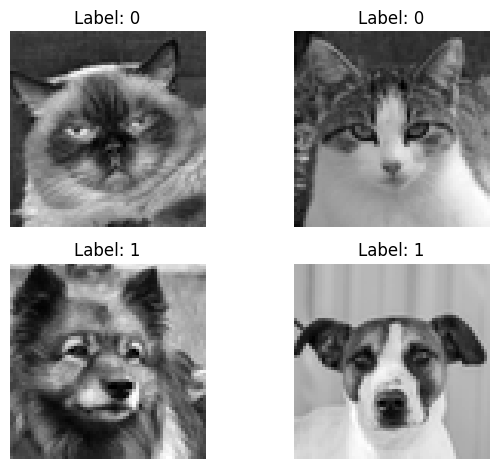

In [25]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

# Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

# Part 1

*Everyone should do this task.*

For the first part, use the large cats and dogs dataset in order to investigate the effects of varying the sample size (n) on the method.

Use at least 4 classifiers and make sure they span a spectrum from rigid to flexible. 

Compare the Performance: Measure the performance in each method as you decrease the sample size. Also compare the performance across methods.
You should use at least 2 performance metrics, e.g. accuracy, log-loss/cross-entropy, Brier score  ($\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K (\hat{p}_{ik}-y_{ik})^2$, where $y_{ik}=1$ when observation $i$ belongs to class k, and 0 otherwise), balanced accuracy, F1-macro, etc. The first 3 are more commonly used to compare models through repeated data splits because they mesh well with testing procedures. 

WE WILL TALK ABOUT THE FOLLOWING IN CLASS NEXT WEEK: I recommend you use rank-based tests to compare the models. That is, for each data split, obtain the ranks for all the models. Use the Friedman test to determine if there are any significant differences between model performance. If there is, perform all pairwise tests between models and adjust using the Holm procedure. Now you can either visualize these p-values in a M-by-M heat map (M models) or in a table with equivalent rank groups (e.g. Model 1, Model 3 > Model 2 > Model 4, Model 5). In Python, the \verbatim{scikit_posthocs} package has some of this implemented but you can also code from scratch. The Friedman-allpairsexact test is not available but you can use Nemenyi instead although it is more conservative.  A Bayesian variant allows for another way to create equivalent ranks through - this is implemented in a package called \verbatim{baycomp}. 

Be prepare to explain:
Which method was best and how did you evaluate this?
Did any method suprise you? 
What was your pipeline? 



In [26]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time
from sklearn.decomposition import PCA


def evaluate_methods_with_outer_inner_cv(methods, X, y, sample_size, outer_folds, inner_folds, number_of_times=3, seed=42):
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=sample_size, stratify=y, random_state=seed)
    f1_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    acc_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    brier_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    for run in range(number_of_times):
        run_seed = seed + run
        np.random.seed(run_seed)
        outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=run_seed)
        for k, (train_idx, test_idx) in enumerate(outer_cv.split(X_sample, y_sample)):
            X_train, X_test = X_sample[train_idx], X_sample[test_idx]
            y_train, y_test = y_sample[train_idx], y_sample[test_idx]
            inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=run_seed + 42) # Adding 42 because it might hurt if same seed as outer
            X_train = X_train.copy()
            X_test = X_test.copy()
            pca = PCA(random_state=0, n_components=35)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            for m, method in enumerate(methods):
                pipeline, params = methods[method]
                t0 = time.time()
                grid_search = GridSearchCV(estimator=pipeline, param_grid=params, cv=inner_cv, scoring='accuracy')
                grid_search.fit(X_train, y_train)
                y_pred = grid_search.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='macro')
                brier = brier_score_loss(y_test, y_pred)
                acc_scores[run*outer_folds + k, m] = acc
                f1_scores[run*outer_folds + k, m] = f1
                brier_scores[run*outer_folds + k, m] = brier
        
                #print(f"Run {run+1}/{number_of_times}, Fold {k+1}/{outer_folds}, Method: {method}, Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Brier Score: {brier:.4f}, Time: {time.time() - t0:.2f} seconds")
    return acc_scores, f1_scores, brier_scores



Evaluating with sample size: 250


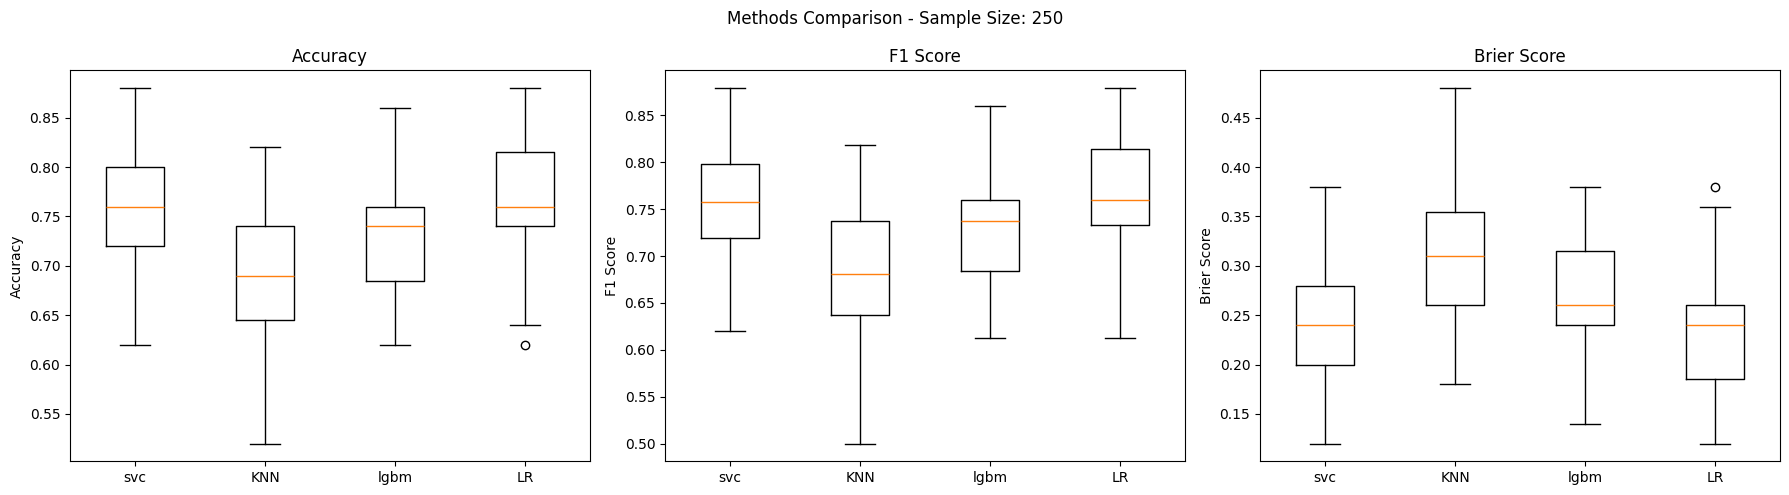


Evaluating with sample size: 500


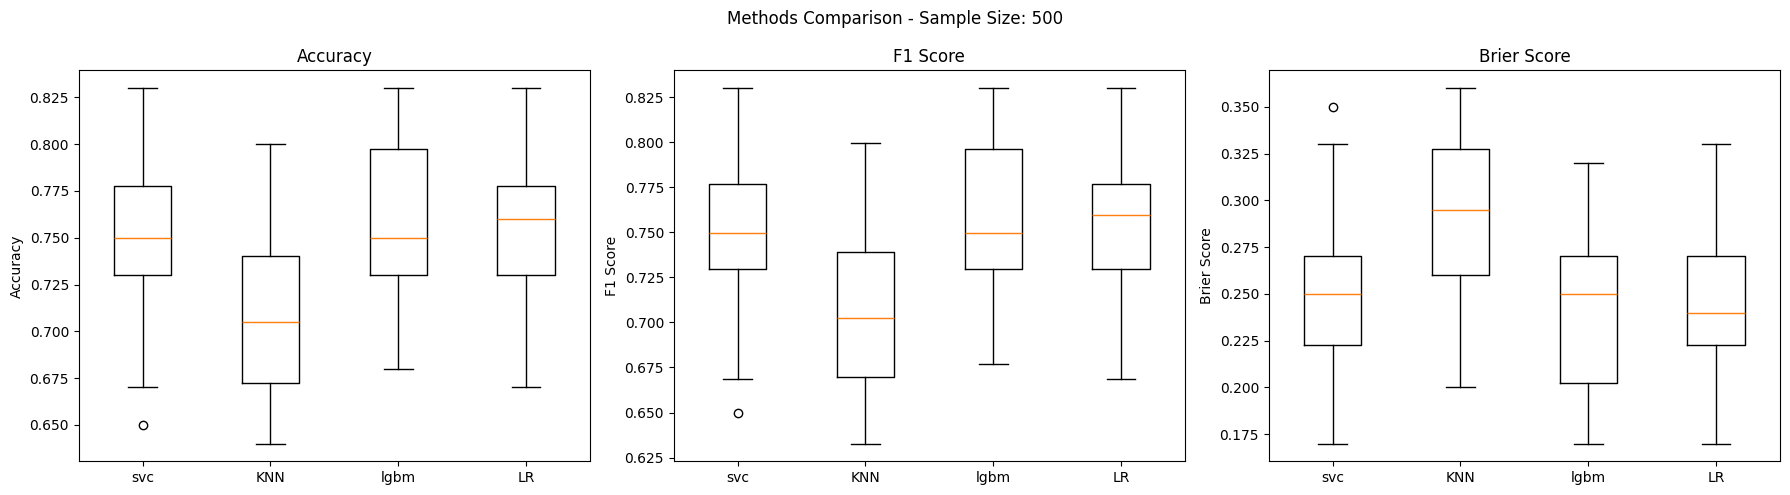


Evaluating with sample size: 1000


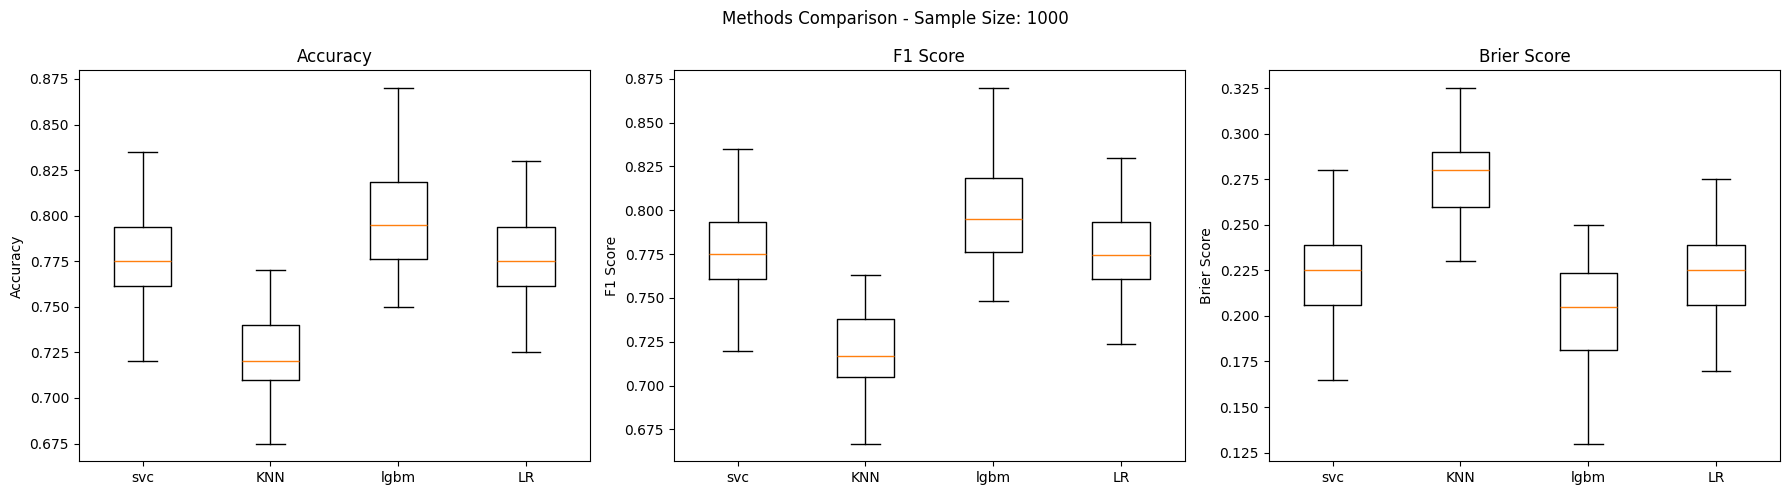


Evaluating with sample size: 5000


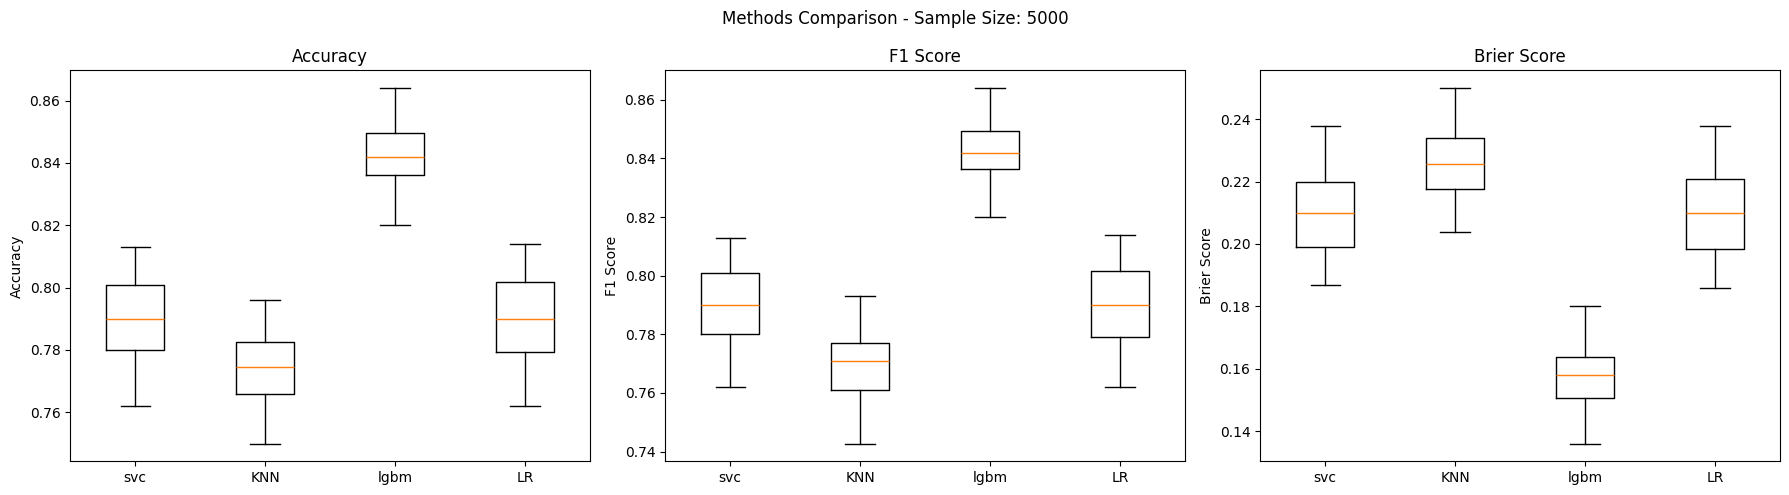


Evaluating with sample size: 8000


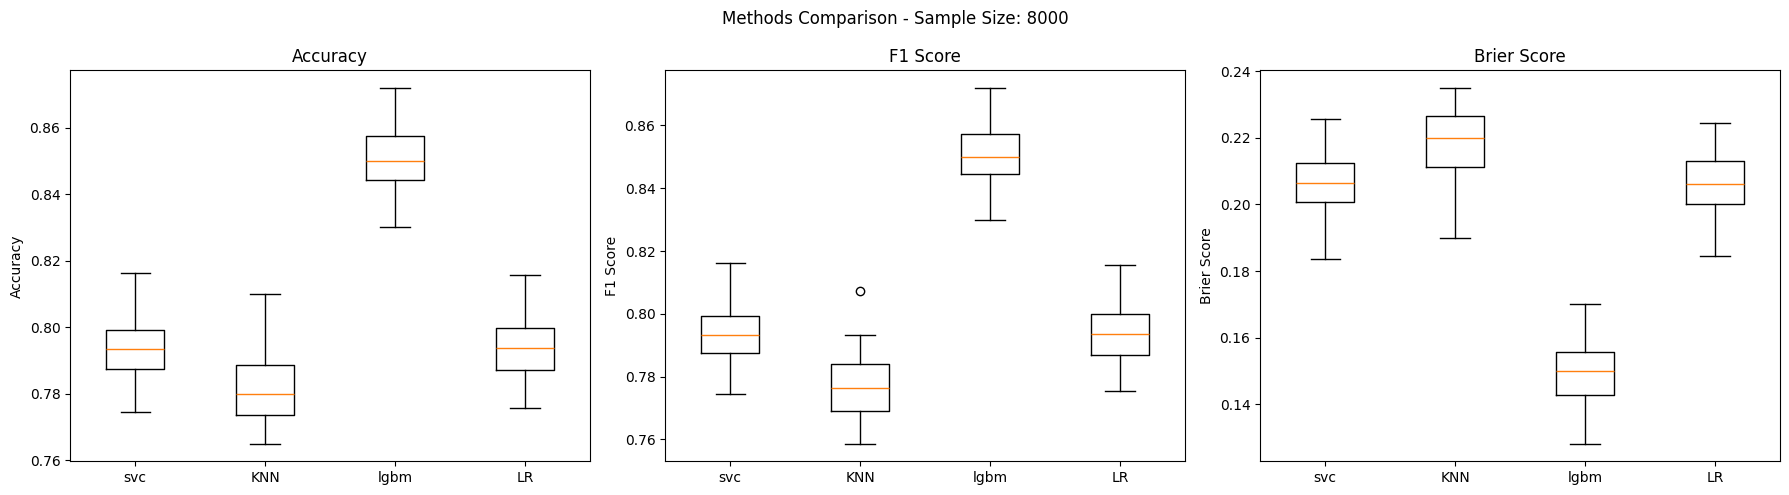

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')
methods = {
    'svc': 
    (Pipeline([
        ('scaler', StandardScaler()),
    ('svc', LinearSVC()),
    ]), {
        'svc__C': [0.1, 1.0, 10.0],
     }),
    'KNN':
    (Pipeline([
        ('clf', KNeighborsClassifier(n_jobs=-1)),
    ]), {'clf__n_neighbors': [3, 5, 11, 21]}),
    'lgbm':
    (Pipeline([
        ('clf', LGBMClassifier(n_estimators=100, num_leaves=15, random_state=0, verbosity=-1)),
    ]), {'clf__learning_rate': [0.01, 0.1]
         }),
    'LR':
    (Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, solver='lbfgs')),
    ]), {'clf__C': [0.01, 0.1, 1.0, 10.0]})
}


sample_sizes = [250, 500, 1000, 5000, 8000]
sample_accs = {}
sample_f1s = {}
sample_briers = {}

for i, sample_size in enumerate(sample_sizes):
    print()
    print(f"Evaluating with sample size: {sample_size}")
    accs, f1s, briers = evaluate_methods_with_outer_inner_cv(methods, images, labels, sample_size, outer_folds=5, inner_folds=3, number_of_times=10, seed=42)
    sample_accs[sample_size] = accs
    sample_f1s[sample_size] = f1s
    sample_briers[sample_size] = briers

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Methods Comparison - Sample Size: {sample_size}")
    ax = axes[0]
    ax.boxplot([accs[:, m] for m in range(len(methods))], tick_labels=methods.keys())
    ax.set_title("Accuracy")
    ax.set_ylabel("Accuracy")

    ax = axes[1]
    ax.boxplot([f1s[:, m] for m in range(len(methods))], tick_labels=methods.keys())
    ax.set_title("F1 Score")
    ax.set_ylabel("F1 Score")

    ax = axes[2]
    ax.boxplot([briers[:, m] for m in range(len(methods))], tick_labels=methods.keys())
    ax.set_title("Brier Score")
    ax.set_ylabel("Brier Score")
    
    plt.tight_layout()
    plt.savefig(f"imgs/method_comparison_{sample_size}.png")

    plt.show()


Friedman statistic: 48.7714, p-value: 1.4591076942428662e-10
--------------------

Significant differences found among the methods for Accuracy at sample size 250.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.003860
  svc                  vs LR                  : p-value = 0.051558
  KNN                  vs lgbm                : p-value = 0.000218
  KNN                  vs LR                  : p-value = 0.000001
  lgbm                 vs LR                  : p-value = 0.000954

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.000002  0.007719  0.051558
KNN   0.000002  1.000000  0.000874  0.000007
lgbm  0.007719  0.000874  1.000000  0.002863
LR    0.051558  0.000007  0.002863  1.000000


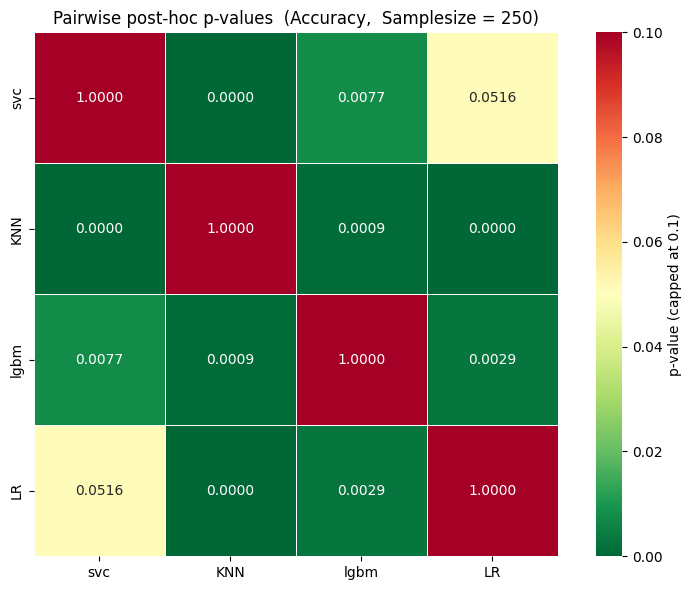

Friedman statistic: 48.1950, p-value: 1.9354528956410113e-10
--------------------

Significant differences found among the methods for F1-Score at sample size 250.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.004871
  svc                  vs LR                  : p-value = 0.044371
  KNN                  vs lgbm                : p-value = 0.000115
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000633

Holm-Bonferroni Corrected p-values

               svc           KNN      lgbm            LR
svc   1.000000e+00  6.070510e-07  0.009742  4.437067e-02
KNN   6.070510e-07  1.000000e+00  0.000459  2.746915e-07
lgbm  9.742094e-03  4.587285e-04  1.000000  1.899891e-03
LR    4.437067e-02  2.746915e-07  0.001900  1.000000e+00


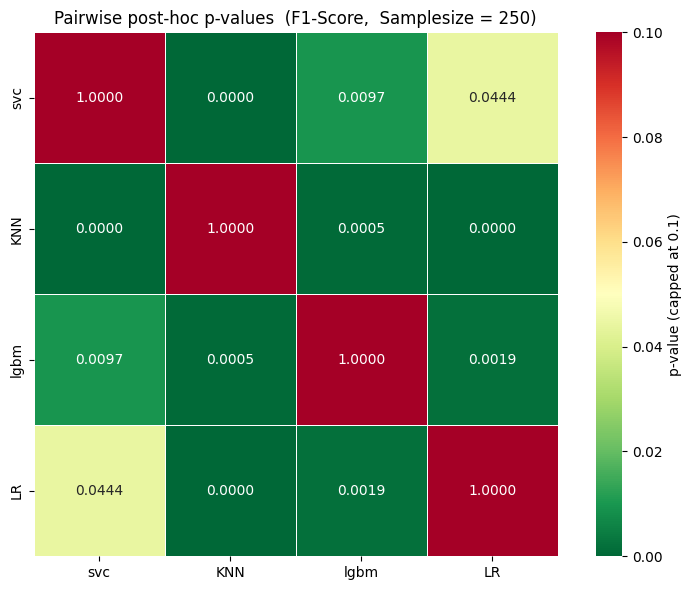

Friedman statistic: 48.7714, p-value: 1.4591076942428662e-10
--------------------

Significant differences found among the methods for Brier Score at sample size 250.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.004242
  svc                  vs LR                  : p-value = 0.044990
  KNN                  vs lgbm                : p-value = 0.000182
  KNN                  vs LR                  : p-value = 0.000001
  lgbm                 vs LR                  : p-value = 0.000816

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.000002  0.008485  0.044990
KNN   0.000002  1.000000  0.000727  0.000005
lgbm  0.008485  0.000727  1.000000  0.002448
LR    0.044990  0.000005  0.002448  1.000000


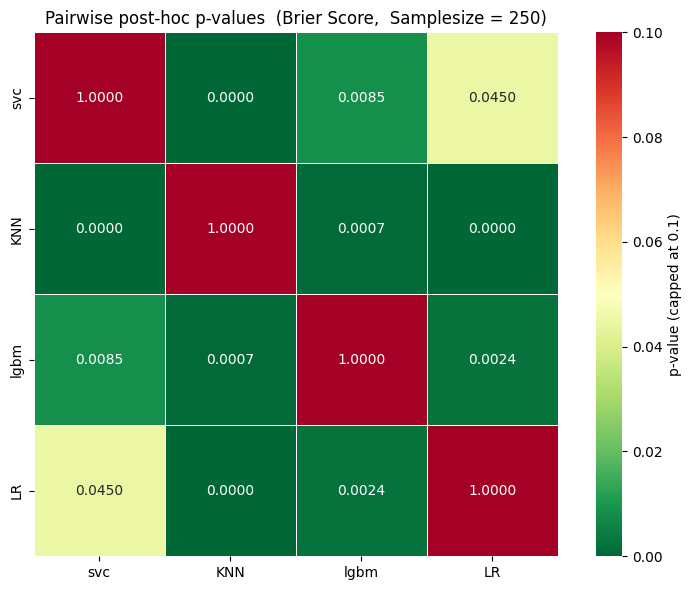

Friedman statistic: 38.2026, p-value: 2.560627516020675e-08
--------------------

Significant differences found among the methods for Accuracy at sample size 500.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000003
  svc                  vs lgbm                : p-value = 0.497244
  svc                  vs LR                  : p-value = 0.136278
  KNN                  vs lgbm                : p-value = 0.000005
  KNN                  vs LR                  : p-value = 0.000002
  lgbm                 vs LR                  : p-value = 0.743371

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.000017  0.994488  0.408834
KNN   0.000017  1.000000  0.000019  0.000011
lgbm  0.994488  0.000019  1.000000  0.994488
LR    0.408834  0.000011  0.994488  1.000000


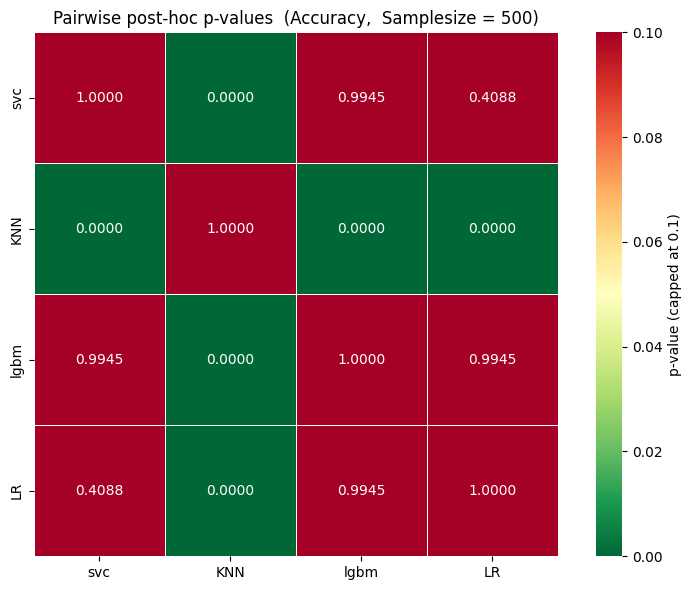

Friedman statistic: 40.4405, p-value: 8.593528957268218e-09
--------------------

Significant differences found among the methods for F1-Score at sample size 500.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.483126
  svc                  vs LR                  : p-value = 0.099843
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.807454

Holm-Bonferroni Corrected p-values

               svc           KNN      lgbm            LR
svc   1.000000e+00  5.643650e-07  0.966251  2.995294e-01
KNN   5.643650e-07  1.000000e+00  0.000002  2.009315e-07
lgbm  9.662513e-01  1.826250e-06  1.000000  9.662513e-01
LR    2.995294e-01  2.009315e-07  0.966251  1.000000e+00


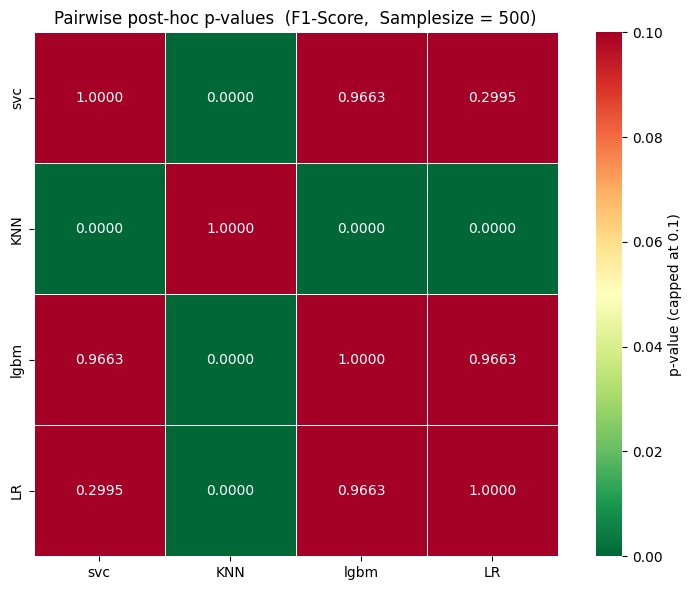

Friedman statistic: 38.2026, p-value: 2.560627516020675e-08
--------------------

Significant differences found among the methods for Brier Score at sample size 500.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000004
  svc                  vs lgbm                : p-value = 0.494259
  svc                  vs LR                  : p-value = 0.180528
  KNN                  vs lgbm                : p-value = 0.000006
  KNN                  vs LR                  : p-value = 0.000002
  lgbm                 vs LR                  : p-value = 0.792635

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.000021  0.988519  0.541585
KNN   0.000021  1.000000  0.000023  0.000013
lgbm  0.988519  0.000023  1.000000  0.988519
LR    0.541585  0.000013  0.988519  1.000000


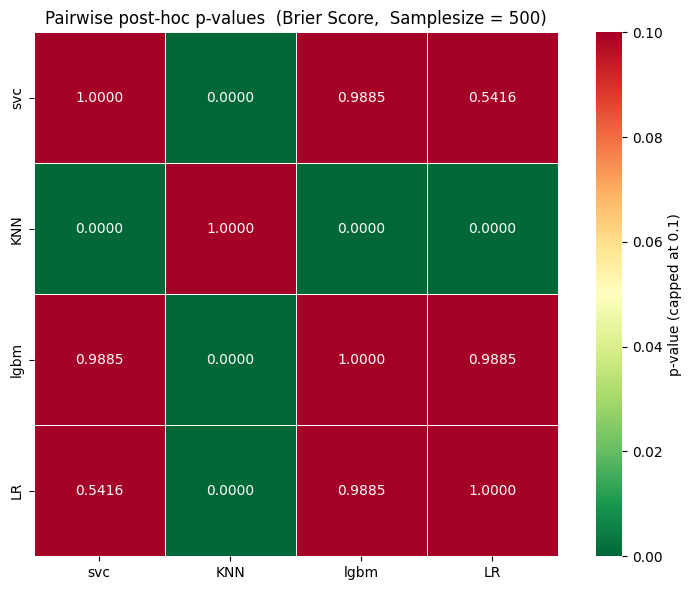

Friedman statistic: 105.0377, p-value: 1.282435011683979e-22
--------------------

Significant differences found among the methods for Accuracy at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000008
  svc                  vs LR                  : p-value = 0.409227
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000007

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.470823e-12  2.049695e-05  4.092265e-01
KNN   1.470823e-12  1.000000e+00  1.065814e-14  6.217249e-13
lgbm  2.049695e-05  1.065814e-14  1.000000e+00  2.049695e-05
LR    4.092265e-01  6.217249e-13  2.049695e-05  1.000000e+00


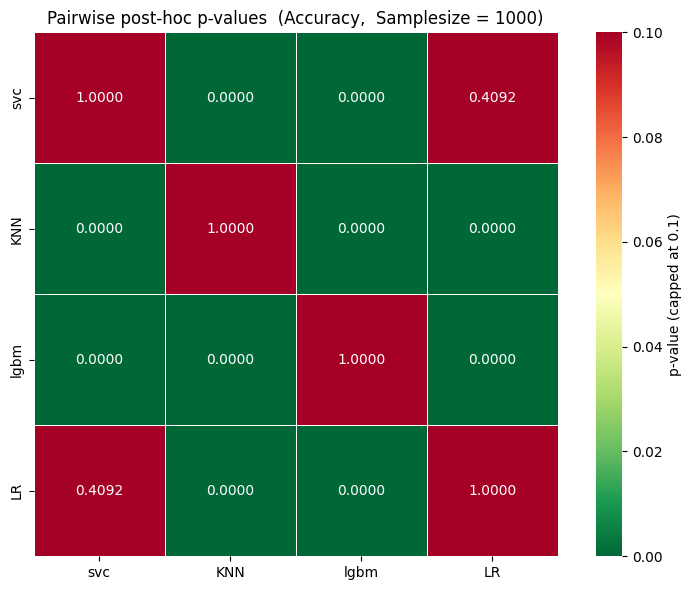

Friedman statistic: 101.0963, p-value: 9.031428823151628e-22
--------------------

Significant differences found among the methods for F1-Score at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000002
  svc                  vs LR                  : p-value = 0.553118
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000009

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  7.815970e-13  6.693131e-06  5.531178e-01
KNN   7.815970e-13  1.000000e+00  1.065814e-14  2.930989e-13
lgbm  6.693131e-06  1.065814e-14  1.000000e+00  1.786724e-05
LR    5.531178e-01  2.930989e-13  1.786724e-05  1.000000e+00


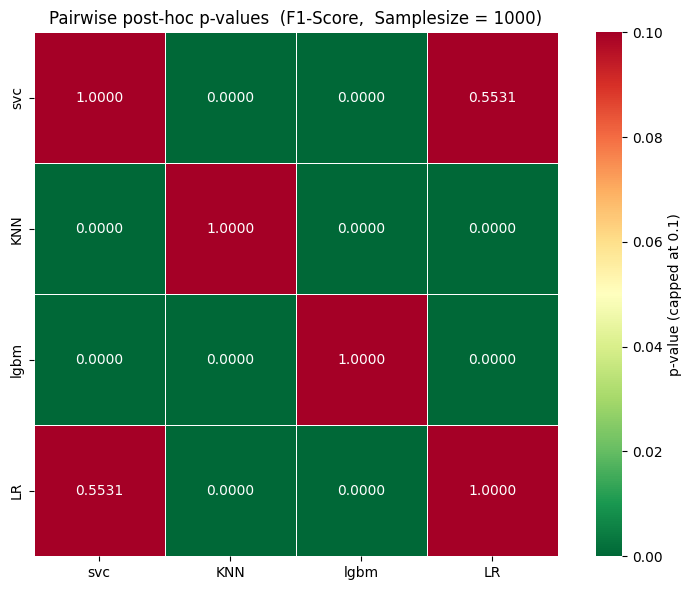

Friedman statistic: 105.0377, p-value: 1.282435011683979e-22
--------------------

Significant differences found among the methods for Brier Score at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000008
  svc                  vs LR                  : p-value = 0.414958
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000006

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.470823e-12  1.761703e-05  4.149577e-01
KNN   1.470823e-12  1.000000e+00  1.065814e-14  9.769963e-13
lgbm  1.761703e-05  1.065814e-14  1.000000e+00  1.761703e-05
LR    4.149577e-01  9.769963e-13  1.761703e-05  1.000000e+00


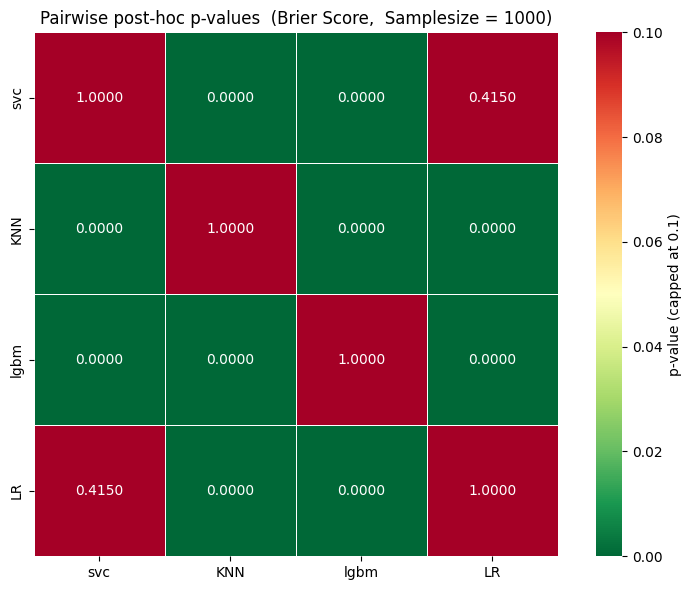

Friedman statistic: 112.0581, p-value: 3.957139395480106e-24
--------------------

Significant differences found among the methods for Accuracy at sample size 5000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.212921
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  2.740748e-08  1.065814e-14  2.129208e-01
KNN   2.740748e-08  1.000000e+00  1.065814e-14  2.468968e-08
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    2.129208e-01  2.468968e-08  1.065814e-14  1.000000e+00


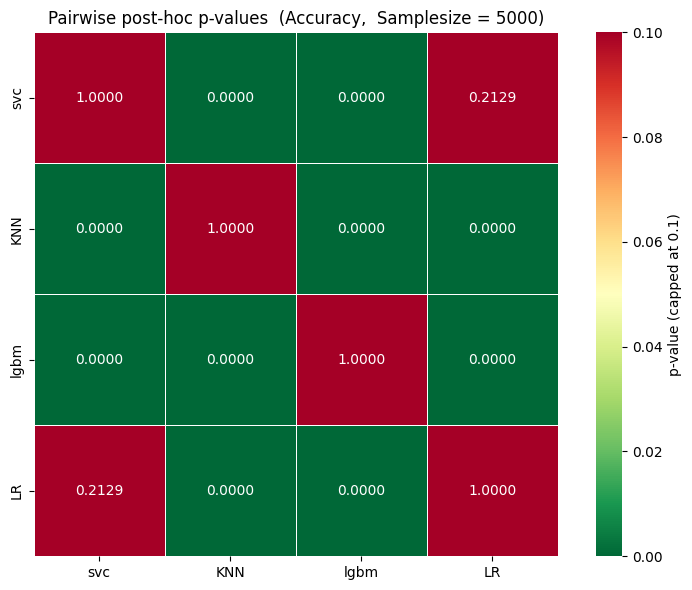

Friedman statistic: 121.3033, p-value: 4.0433471220428834e-26
--------------------

Significant differences found among the methods for F1-Score at sample size 5000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.099762
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  3.537437e-11  1.065814e-14  9.976205e-02
KNN   3.537437e-11  1.000000e+00  1.065814e-14  3.518252e-11
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    9.976205e-02  3.518252e-11  1.065814e-14  1.000000e+00


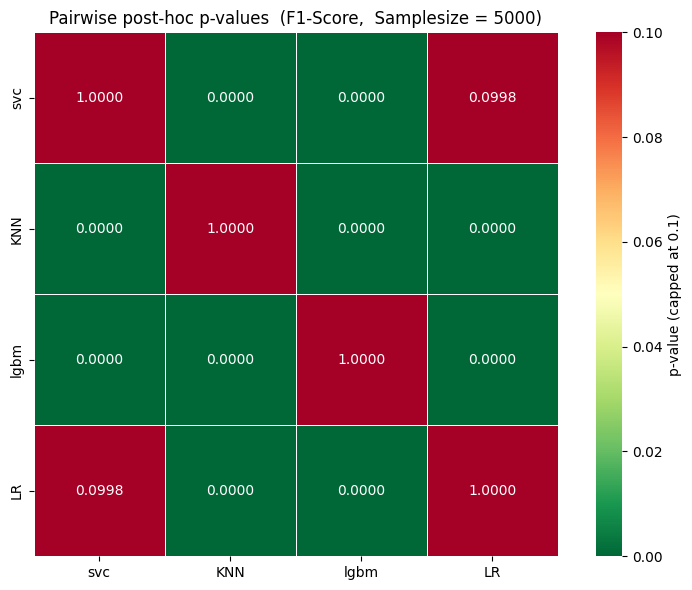

Friedman statistic: 112.0581, p-value: 3.957139395480106e-24
--------------------

Significant differences found among the methods for Brier Score at sample size 5000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.189699
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  2.979061e-08  1.065814e-14  1.896989e-01
KNN   2.979061e-08  1.000000e+00  1.065814e-14  2.691120e-08
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    1.896989e-01  2.691120e-08  1.065814e-14  1.000000e+00


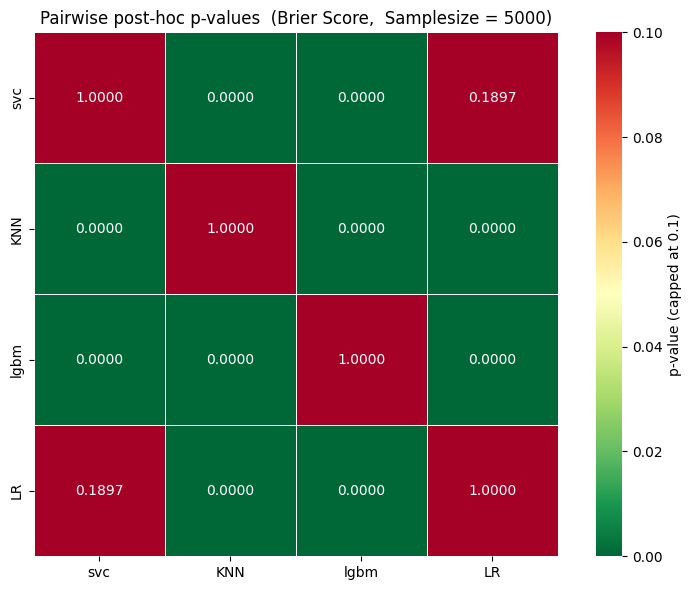

Friedman statistic: 115.6025, p-value: 6.829239026284032e-25
--------------------

Significant differences found among the methods for Accuracy at sample size 8000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.058855
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.377460e-07  1.065814e-14  5.885508e-02
KNN   1.377460e-07  1.000000e+00  1.065814e-14  1.377460e-07
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    5.885508e-02  1.377460e-07  1.065814e-14  1.000000e+00


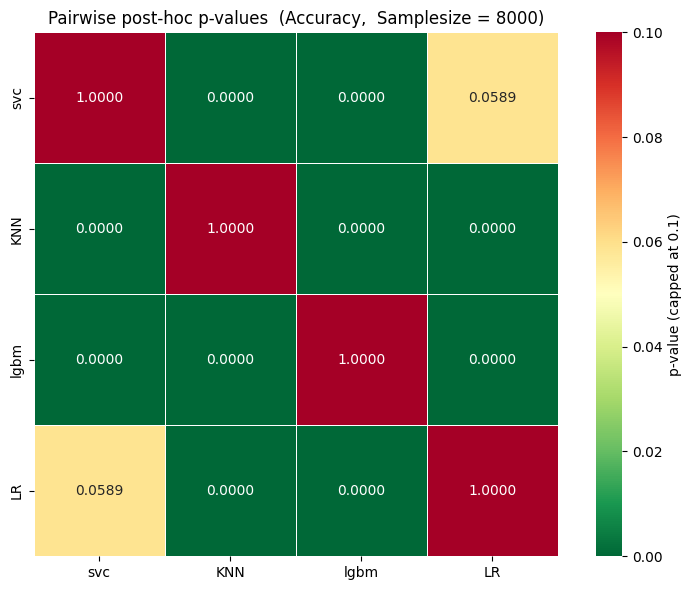

Friedman statistic: 124.9152, p-value: 6.740669212240343e-27
--------------------

Significant differences found among the methods for F1-Score at sample size 8000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.052890
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  4.060752e-12  1.065814e-14  5.289035e-02
KNN   4.060752e-12  1.000000e+00  1.065814e-14  4.060752e-12
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    5.289035e-02  4.060752e-12  1.065814e-14  1.000000e+00


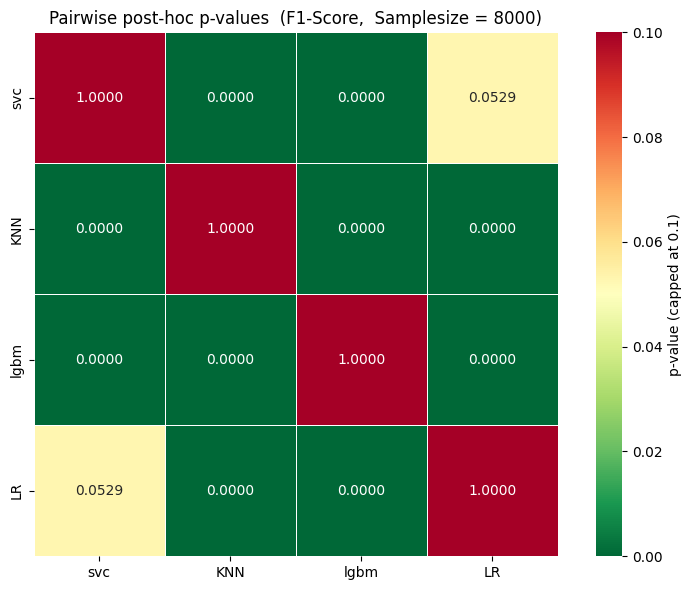

Friedman statistic: 115.6025, p-value: 6.829239026284032e-25
--------------------

Significant differences found among the methods for Brier Score at sample size 8000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.029215
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.229386e-07  1.065814e-14  2.921513e-02
KNN   1.229386e-07  1.000000e+00  1.065814e-14  1.229386e-07
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    2.921513e-02  1.229386e-07  1.065814e-14  1.000000e+00


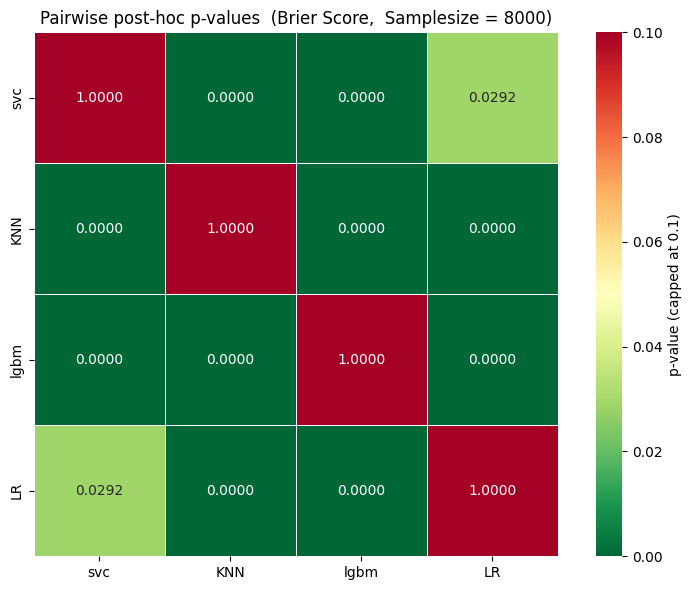

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, rankdata
import scikit_posthocs as sp
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def friedman(scores, method_names, sample_size, comparison_metric_name="Accuracy"):
    stat, pval = friedmanchisquare(*scores.T) 
    print(f"Friedman statistic: {stat:.4f}, p-value: {pval}")
    if pval > 0.05:
        print("-"*20)
        print(f"\nNo significant differences found among the methods for {comparison_metric_name} at sample size {sample_size}.")
    else:
        print("-"*20)
        print(f"\nSignificant differences found among the methods for {comparison_metric_name} at sample size {sample_size}.")
        print("Performing pairwise post-hoc test")
        n_methods = scores.shape[1]
        method_names = list(method_names)
        pvals_raw = []
        comparisons = []

        print("\nPairwise Comparisons:")
        for i, j in combinations(range(n_methods), 2):
            w_stat, w_pval = wilcoxon(scores[:, i], scores[:, j])
            pvals_raw.append(w_pval)
            comparisons.append((method_names[i], method_names[j]))
            print(f"  {method_names[i]:20s} vs {method_names[j]:20s}: p-value = {w_pval:.6f}")
        pvals_raw = np.array(pvals_raw)
        reject, pvals_corrected, _, _ = multipletests(pvals_raw, method='holm')

        p_matrix = pd.DataFrame(np.full((n_methods, n_methods), np.nan), 
                                index=method_names, 
                                columns=method_names)

        idx_counter = 0
        for i, j in combinations(range(n_methods), 2):
            p_matrix.iloc[j, i] = pvals_corrected[idx_counter]
            p_matrix.iloc[i, j] = pvals_corrected[idx_counter]
            idx_counter += 1

        np.fill_diagonal(p_matrix.values, 1.0)

        print("\n" + "=" * 70)
        print("Holm-Bonferroni Corrected p-values")
        print("=" * 70)
        print("\n" + p_matrix.to_string())
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(p_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r',
                    vmin=0, vmax=0.1, cbar_kws={'label': 'p-value (capped at 0.1)'},
                    ax=ax, square=True, linewidths=0.5)
        plt.title(f'Pairwise post-hoc p-values  ({comparison_metric_name},  Samplesize = {sample_size})')
        plt.tight_layout()
        plt.savefig(f"imgs/posthoc_pvalues_{comparison_metric_name}_{sample_size}.png")
        plt.show()


for sample_size in sample_sizes:
    friedman(sample_accs[sample_size], list(methods.keys()), sample_size=sample_size, comparison_metric_name="Accuracy")
    friedman(sample_f1s[sample_size], list(methods.keys()), sample_size=sample_size, comparison_metric_name="F1-Score")
    friedman(sample_briers[sample_size], list(methods.keys()), sample_size=sample_size, comparison_metric_name="Brier Score")
    

## Part 2 - Themes
You will be allocated one of the three themes and should perform ***all*** tasks as described in this theme.

### Theme 1 - Imbalance
Use the Cats and Dogs dataset.

Investigate the effects of imbalance on PART 1 - where you create the imbalance. Try with different train, calibration and test sizes. 

Does the model ranking change?

### Theme 2 - Conformal Prediction
Use the MNIST data set.

Select 3 classifiers. Perform conformal prediction. Do you observe similar conformal predictions between the methods? Summarize the conformal predictions. Are certain classes more often to be lumped together in the same set of predictions and does it depend on the classifier used? 

Try with different train, calibration and test sizes. 

### Theme 3 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? Which methods struggle? How does sample size affect this?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling*. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.

Do the above on 3 levels of data (full data, medium data, small data).

In [10]:
# ...then the numbers data
import pandas as pd

PATHIM = "mnist_large//images.csv"
PATHLB = "mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 784)
'labels' size: (10000, 1)
Classes [0 1 2 3 4 5 6 7 8 9]


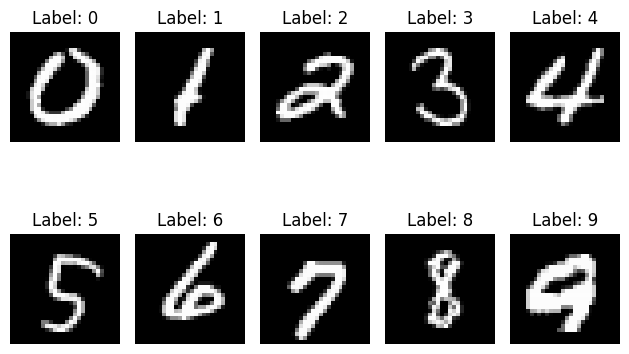

In [11]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]

# Visualize the first images in each class
idx = [np.where(labels == i)[0][0] for i in range(10)]
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 5)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [12]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time
from sklearn.feature_selection import VarianceThreshold


def evaluate_methods_with_outer_inner_cv_with_misslabels(methods, X, y, sample_size, outer_folds, inner_folds, miss_label_rate=0.1, number_of_times=3, seed=42):
    if sample_size < len(y):
        X_sample, _, y_sample, _ = train_test_split(X, y, train_size=sample_size, stratify=y, random_state=seed)
    else:
        X_sample, y_sample = X, y
    f1_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    acc_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    for run in range(number_of_times):
        run_seed = seed + run
        np.random.seed(run_seed)
        outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=run_seed)
        for k, (train_idx, test_idx) in enumerate(outer_cv.split(X_sample, y_sample)):
            X_train, X_test = X_sample[train_idx], X_sample[test_idx]
            y_train, y_test = y_sample[train_idx], y_sample[test_idx]
            n_misslabels = int(miss_label_rate * len(y_train))
            misslabel_indices = np.random.choice(np.arange(len(y_train)), size=n_misslabels, replace=False)
            classes = np.unique(y_train)
            for idx in misslabel_indices:
                other_classes = classes[classes != y_train[idx]]
                y_train[idx] = np.random.choice(other_classes)
            inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=run_seed + 42) # Adding 42 because it might hurt if same seed as outer

            X_train = X_train.copy()
            X_test = X_test.copy()
            pca = PCA(random_state=0, n_components=35)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            for m, method in enumerate(methods):
                pipeline, params = methods[method]
                t0 = time.time()
                grid_search = GridSearchCV(estimator=pipeline, param_grid=params, cv=inner_cv, scoring='accuracy')
                grid_search.fit(X_train, y_train)
                y_pred = grid_search.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='macro')
                acc_scores[run*outer_folds + k, m] = acc
                f1_scores[run*outer_folds + k, m] = f1
                #print(f"Run {run+1}/{number_of_times}, Fold {k+1}/{outer_folds}, Method: {method}, Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Time: {time.time() - t0:.2f} seconds")
    return acc_scores, f1_scores


Evaluating with sample size: 10000, misslabel rate: 0.1


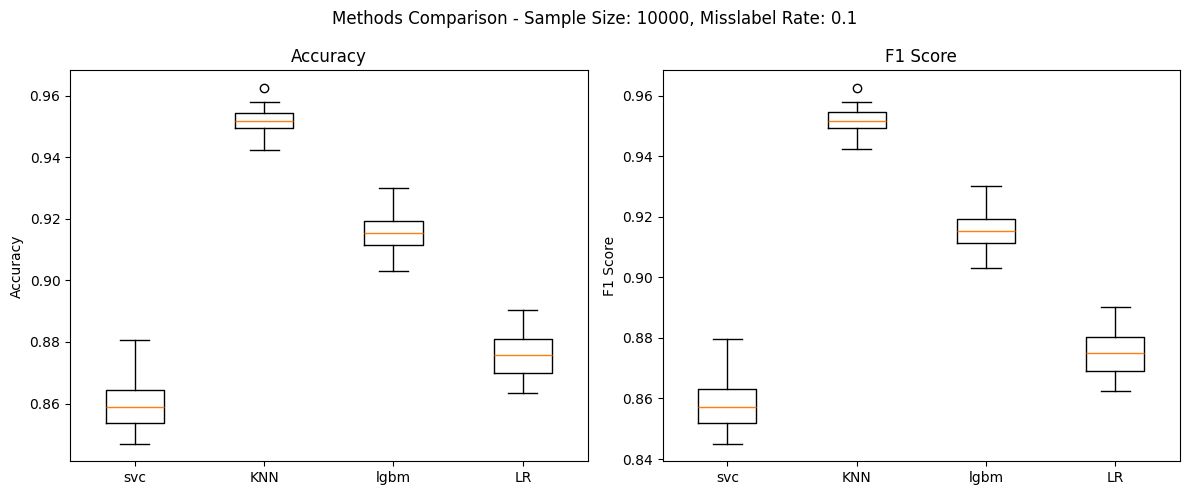


Evaluating with sample size: 1000, misslabel rate: 0.1


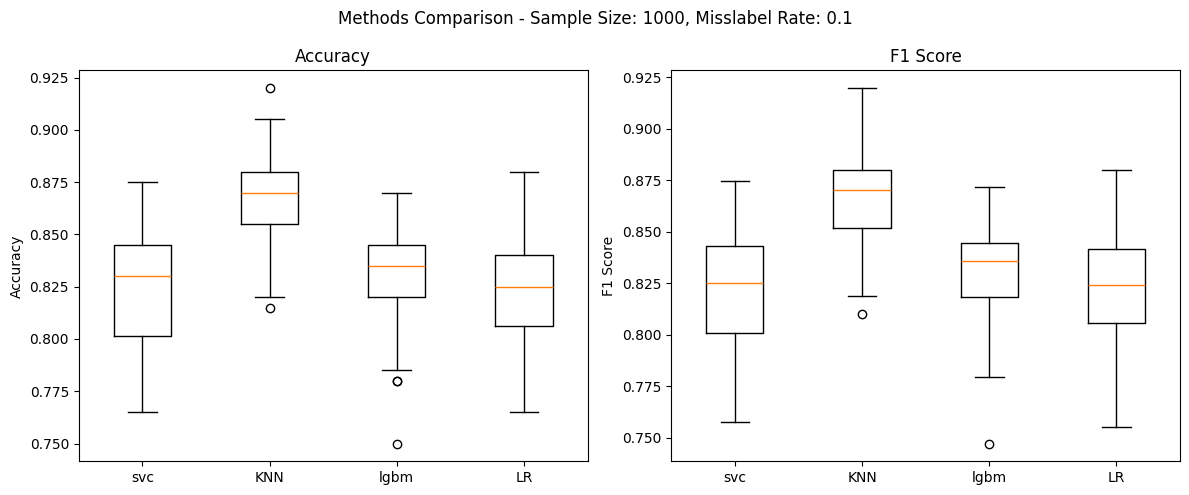


Evaluating with sample size: 100, misslabel rate: 0.1


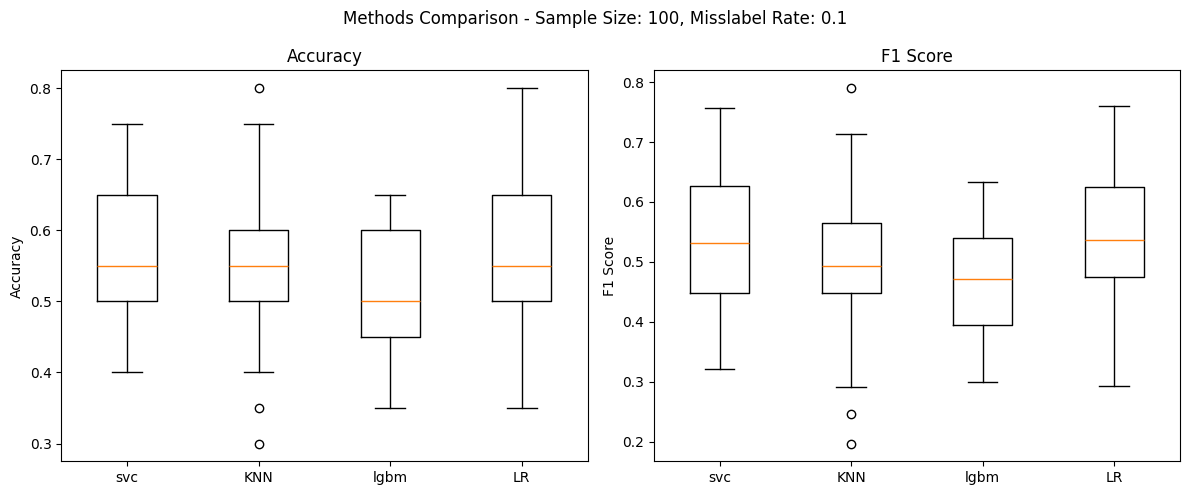


Evaluating with sample size: 10000, misslabel rate: 0.3


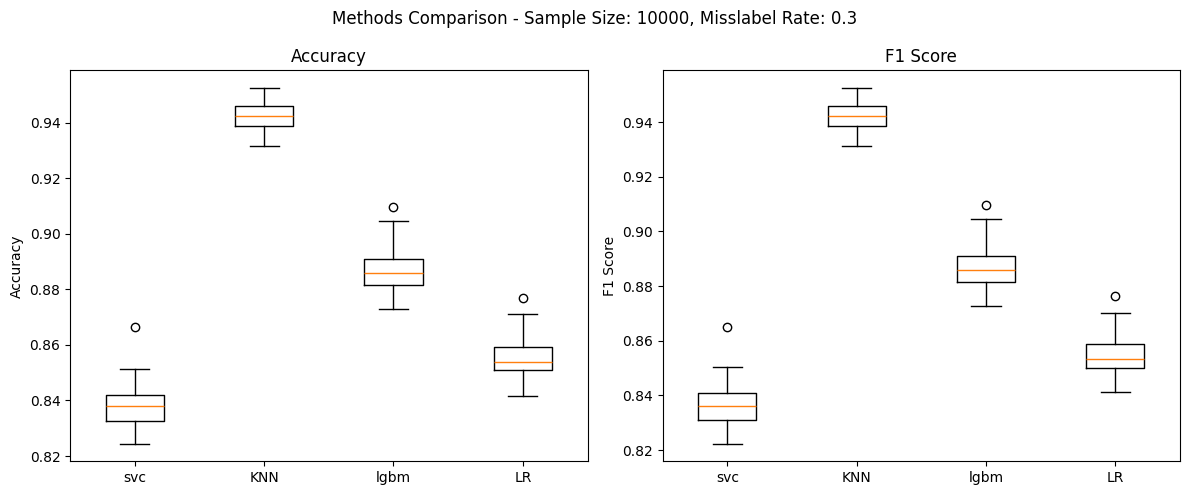


Evaluating with sample size: 1000, misslabel rate: 0.3


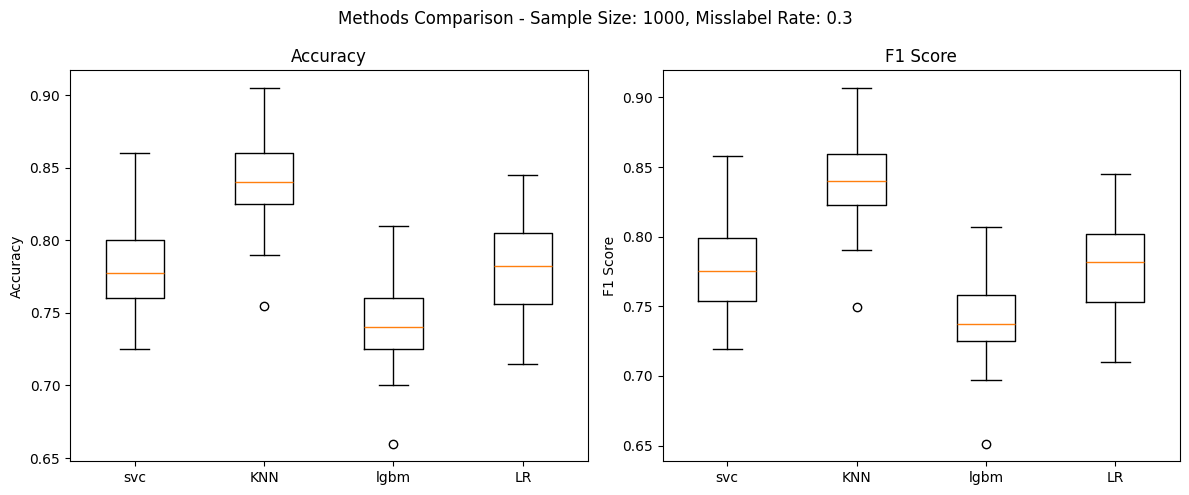


Evaluating with sample size: 100, misslabel rate: 0.3


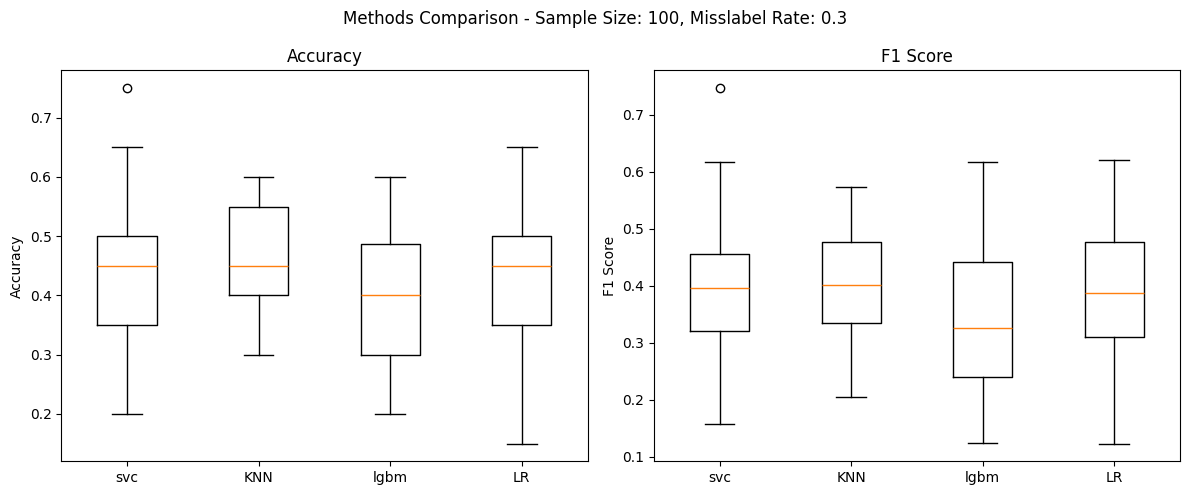


Evaluating with sample size: 10000, misslabel rate: 0.5


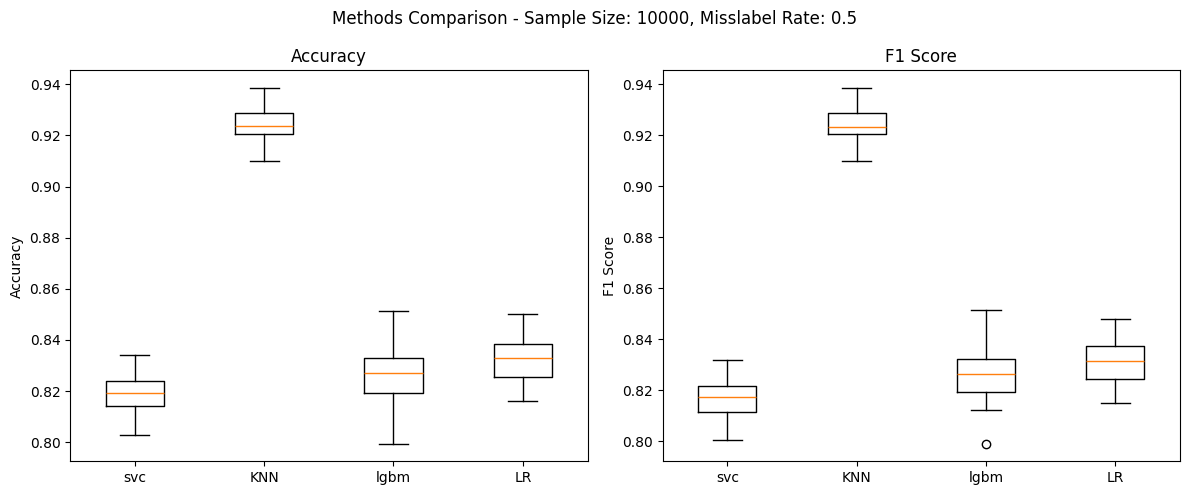


Evaluating with sample size: 1000, misslabel rate: 0.5


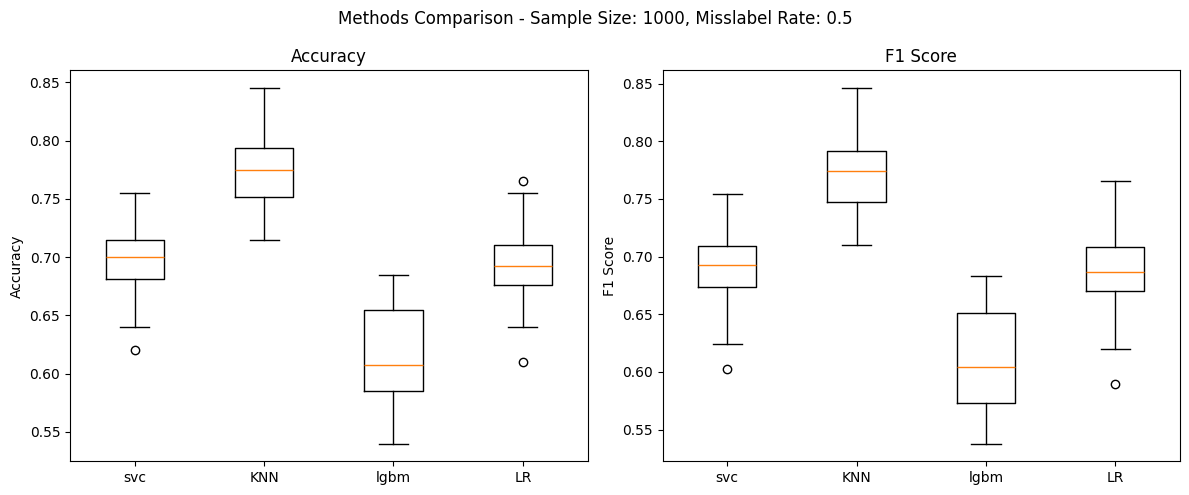


Evaluating with sample size: 100, misslabel rate: 0.5


C:\Users\Hassa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Hassa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Hassa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Hassa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-

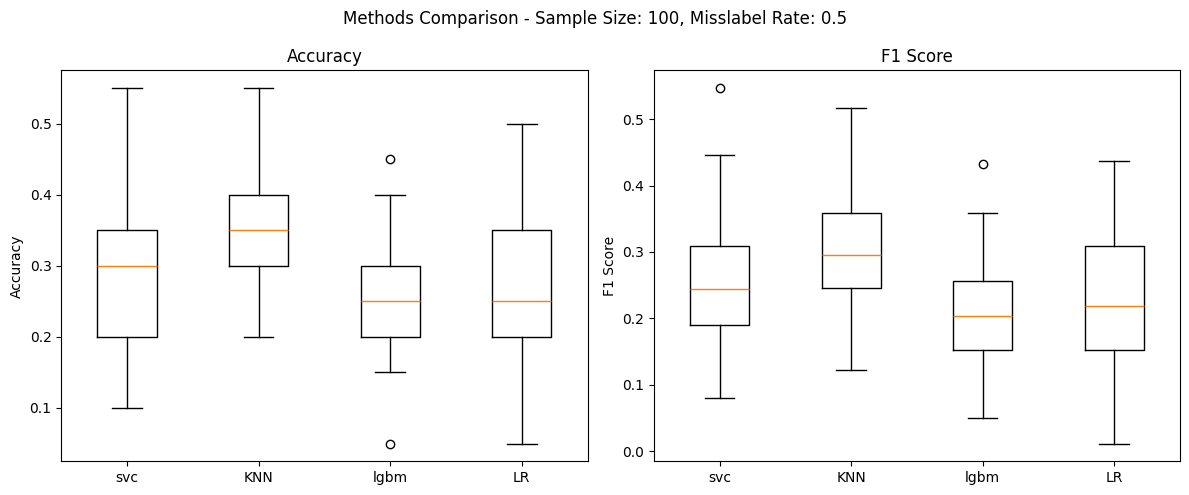

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')
methods = {
    'svc': 
    (Pipeline([
        ('scaler', StandardScaler()),
    ('svc', LinearSVC()),
    ]), {
        'svc__C': [0.1, 1.0, 10.0],
     }),
    'KNN':
    (Pipeline([
        ('clf', KNeighborsClassifier(n_jobs=-1)),
    ]), {'clf__n_neighbors': [3, 5, 11, 21]}),
    'lgbm':
    (Pipeline([
        ('clf', LGBMClassifier(n_estimators=100, num_leaves=15, random_state=0, verbosity=-1)),
    ]), {'clf__learning_rate': [0.01, 0.1]
         }),
    'LR':
    (Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, solver='lbfgs')),
    ]), {'clf__C': [0.01, 0.1, 1.0, 10.0]})
}


sample_sizes = [len(images), len(images)//10, len(images)//100]
sample_accs = {}
sample_f1s = {}
miss_label_rates = [0.1, 0.3, 0.5] # Modify this to run with different misslabel rates

for j, miss_label_rate in enumerate(miss_label_rates):
    for i, sample_size in enumerate(sample_sizes):
        print()
        print(f"Evaluating with sample size: {sample_size}, misslabel rate: {miss_label_rate}")
        accs, f1s = evaluate_methods_with_outer_inner_cv_with_misslabels(methods, images, labels, sample_size, outer_folds=5, inner_folds=3, miss_label_rate=miss_label_rate, number_of_times=10, seed=42)
        sample_accs[sample_size, miss_label_rate] = accs
        sample_f1s[sample_size, miss_label_rate] = f1s
        # plot boxplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"Methods Comparison - Sample Size: {sample_size}, Misslabel Rate: {miss_label_rate}")
        ax = axes[0]
        ax.boxplot([accs[:, m] for m in range(len(methods))], tick_labels=methods.keys())
        ax.set_title("Accuracy")
        ax.set_ylabel("Accuracy")

        ax = axes[1]
        ax.boxplot([f1s[:, m] for m in range(len(methods))], tick_labels=methods.keys())
        ax.set_title("F1 Score")
        ax.set_ylabel("F1 Score")
        plt.tight_layout()
        plt.savefig(f"imgs/method_comparison_misslabel_{miss_label_rate}_{sample_size}.png")
        plt.show()

Friedman statistic: 150.0000, p-value: 2.634913928488041e-32
--------------------

Significant differences found among the methods for Accuracy at sample size 10000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  1.065814e-14  1.065814e-14
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    1.065814e-14  1.065814e-14  1.065814e-14  1.000000e+00


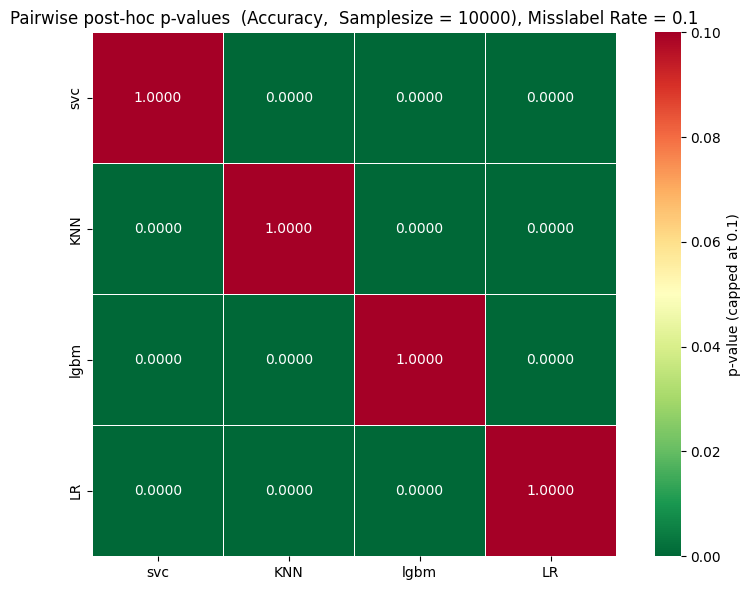

Friedman statistic: 150.0000, p-value: 2.634913928488041e-32
--------------------

Significant differences found among the methods for F1-Score at sample size 10000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  1.065814e-14  1.065814e-14
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    1.065814e-14  1.065814e-14  1.065814e-14  1.000000e+00


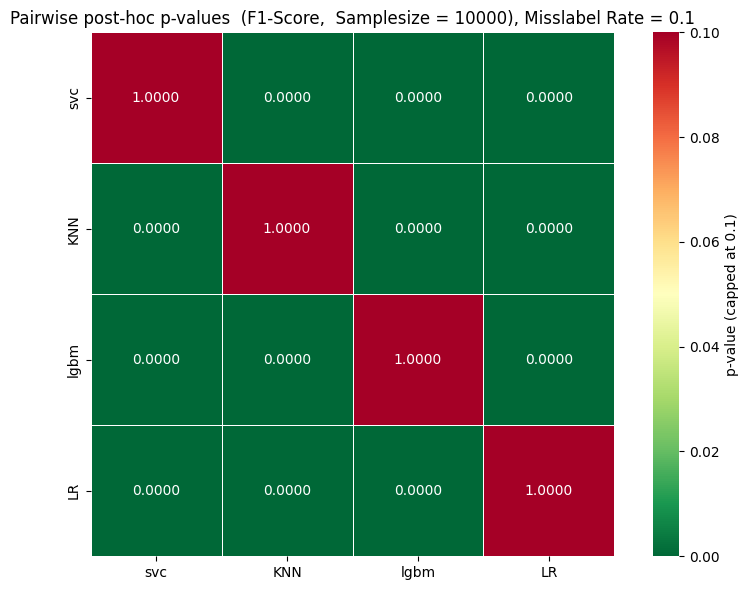

Friedman statistic: 67.9568, p-value: 1.1686442378465216e-14
--------------------

Significant differences found among the methods for Accuracy at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.172404
  svc                  vs LR                  : p-value = 0.803414
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.143394

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.213216e-10  4.301807e-01  8.034142e-01
KNN   1.213216e-10  1.000000e+00  1.765149e-08  1.213216e-10
lgbm  4.301807e-01  1.765149e-08  1.000000e+00  4.301807e-01
LR    8.034142e-01  1.213216e-10  4.301807e-01  1.000000e+00


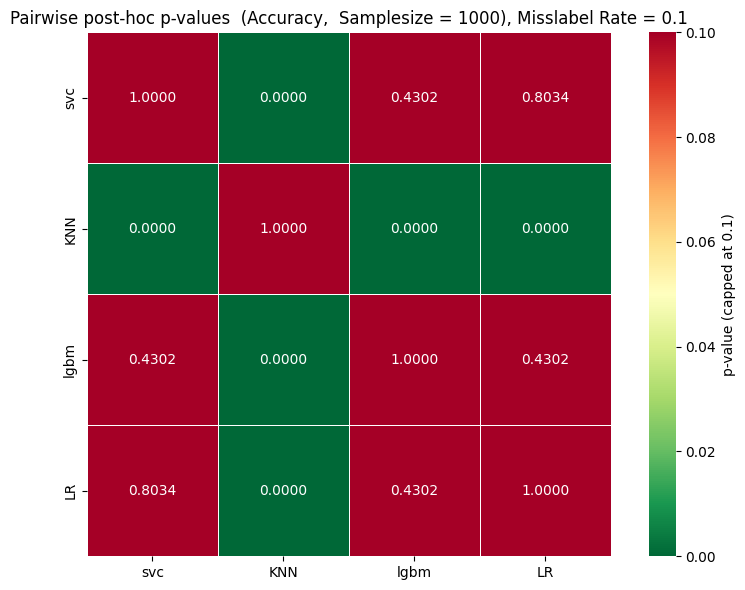

Friedman statistic: 66.6960, p-value: 2.1752472440728243e-14
--------------------

Significant differences found among the methods for F1-Score at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.097094
  svc                  vs LR                  : p-value = 0.954225
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.082268

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  7.724488e-11  2.468026e-01  9.542250e-01
KNN   7.724488e-11  1.000000e+00  2.168932e-11  1.052243e-10
lgbm  2.468026e-01  2.168932e-11  1.000000e+00  2.468026e-01
LR    9.542250e-01  1.052243e-10  2.468026e-01  1.000000e+00


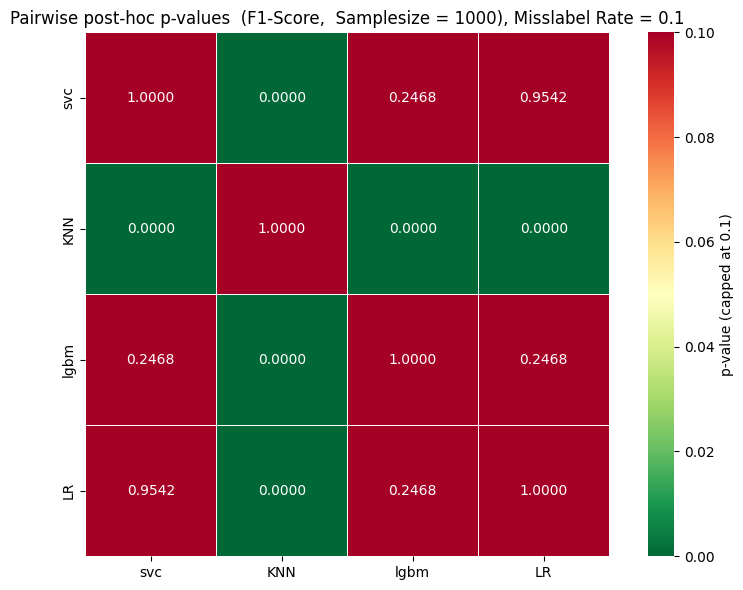

Friedman statistic: 24.4203, p-value: 2.0408853960709677e-05
--------------------

Significant differences found among the methods for Accuracy at sample size 100.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.231647
  svc                  vs lgbm                : p-value = 0.000050
  svc                  vs LR                  : p-value = 0.608093
  KNN                  vs lgbm                : p-value = 0.005180
  KNN                  vs LR                  : p-value = 0.096166
  lgbm                 vs LR                  : p-value = 0.000030

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.463295  0.000252  0.608093
KNN   0.463295  1.000000  0.020719  0.288497
lgbm  0.000252  0.020719  1.000000  0.000178
LR    0.608093  0.288497  0.000178  1.000000


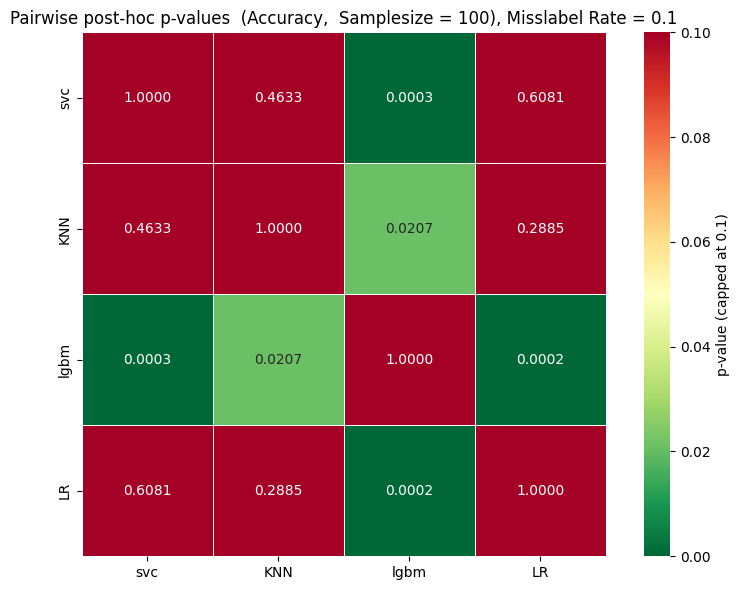

Friedman statistic: 18.8641, p-value: 0.0002916701732740059
--------------------

Significant differences found among the methods for F1-Score at sample size 100.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.006919
  svc                  vs lgbm                : p-value = 0.000125
  svc                  vs LR                  : p-value = 0.803877
  KNN                  vs lgbm                : p-value = 0.064886
  KNN                  vs LR                  : p-value = 0.001457
  lgbm                 vs LR                  : p-value = 0.000017

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.020757  0.000623  0.803877
KNN   0.020757  1.000000  0.129772  0.005827
lgbm  0.000623  0.129772  1.000000  0.000101
LR    0.803877  0.005827  0.000101  1.000000


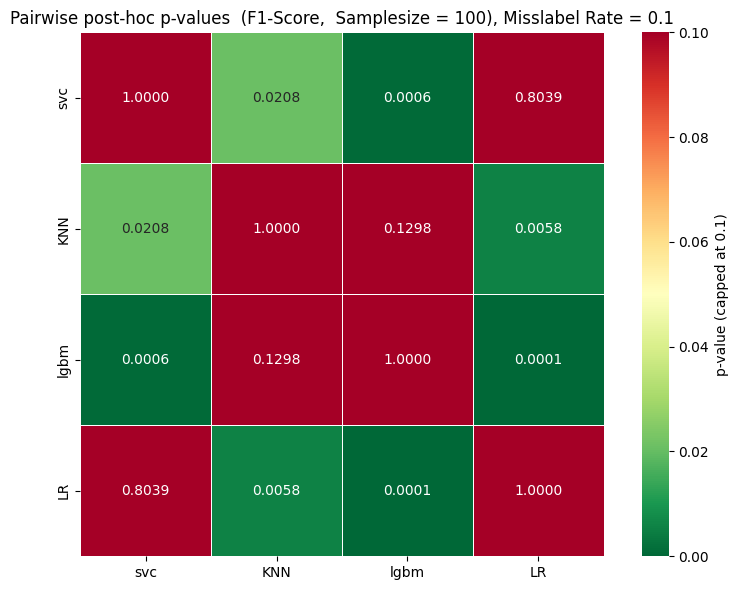

Friedman statistic: 150.0000, p-value: 2.634913928488041e-32
--------------------

Significant differences found among the methods for Accuracy at sample size 10000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  1.065814e-14  1.065814e-14
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    1.065814e-14  1.065814e-14  1.065814e-14  1.000000e+00


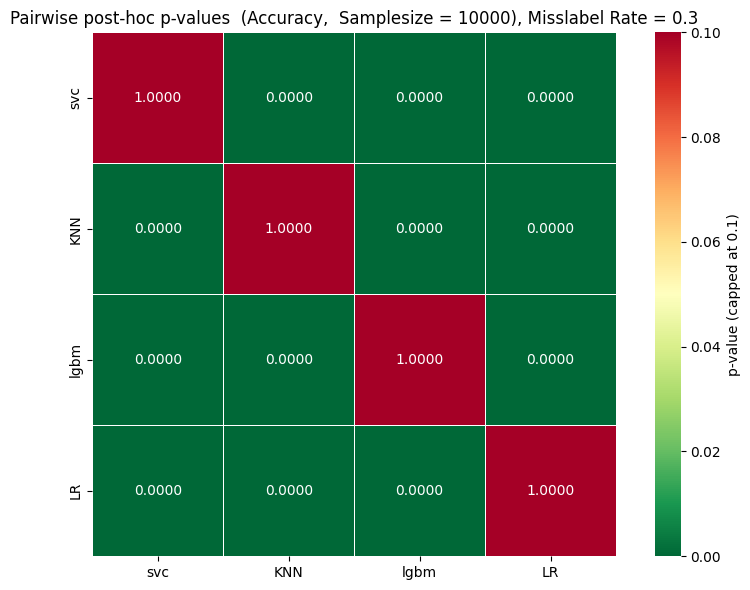

Friedman statistic: 150.0000, p-value: 2.634913928488041e-32
--------------------

Significant differences found among the methods for F1-Score at sample size 10000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  1.065814e-14  1.065814e-14
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  1.065814e-14  1.065814e-14  1.000000e+00  1.065814e-14
LR    1.065814e-14  1.065814e-14  1.065814e-14  1.000000e+00


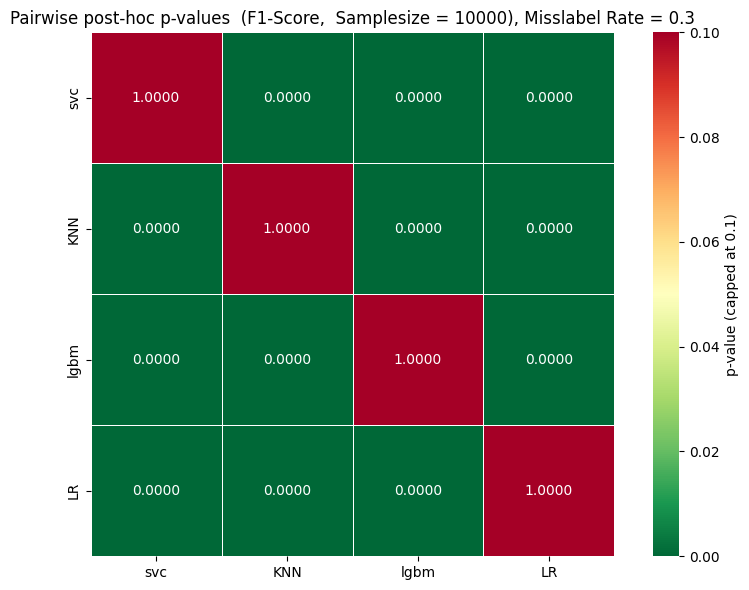

Friedman statistic: 114.2638, p-value: 1.3261016459975037e-24
--------------------

Significant differences found among the methods for Accuracy at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.458427
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  7.105427e-14  5.115382e-08  4.584271e-01
KNN   7.105427e-14  1.000000e+00  1.065814e-14  2.664535e-14
lgbm  5.115382e-08  1.065814e-14  1.000000e+00  5.661264e-08
LR    4.584271e-01  2.664535e-14  5.661264e-08  1.000000e+00


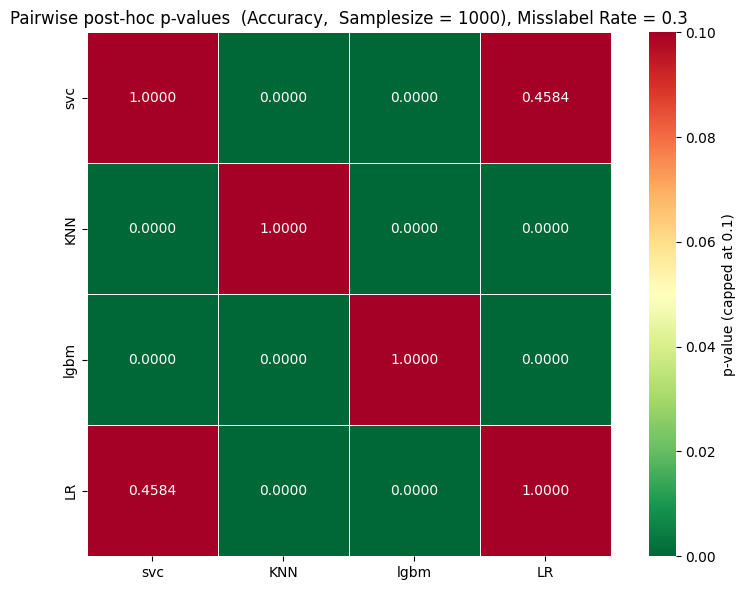

Friedman statistic: 110.3760, p-value: 9.107854309505078e-24
--------------------

Significant differences found among the methods for F1-Score at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.382904
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  3.552714e-14  1.437687e-09  3.829037e-01
KNN   3.552714e-14  1.000000e+00  1.065814e-14  1.776357e-14
lgbm  1.437687e-09  1.065814e-14  1.000000e+00  2.629939e-09
LR    3.829037e-01  1.776357e-14  2.629939e-09  1.000000e+00


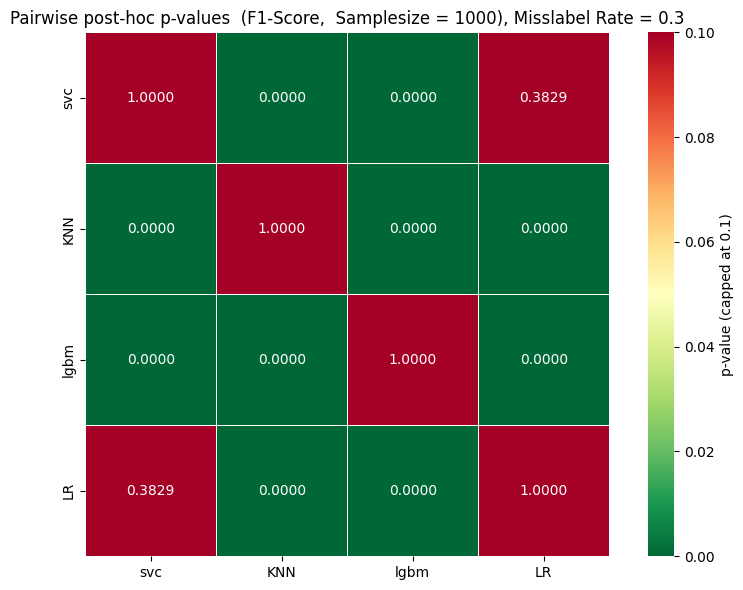

Friedman statistic: 16.5553, p-value: 0.0008722840745841406
--------------------

Significant differences found among the methods for Accuracy at sample size 100.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.089909
  svc                  vs lgbm                : p-value = 0.028598
  svc                  vs LR                  : p-value = 0.730272
  KNN                  vs lgbm                : p-value = 0.000644
  KNN                  vs LR                  : p-value = 0.172997
  lgbm                 vs LR                  : p-value = 0.010634

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.269726  0.114391  0.730272
KNN   0.269726  1.000000  0.003866  0.345995
lgbm  0.114391  0.003866  1.000000  0.053168
LR    0.730272  0.345995  0.053168  1.000000


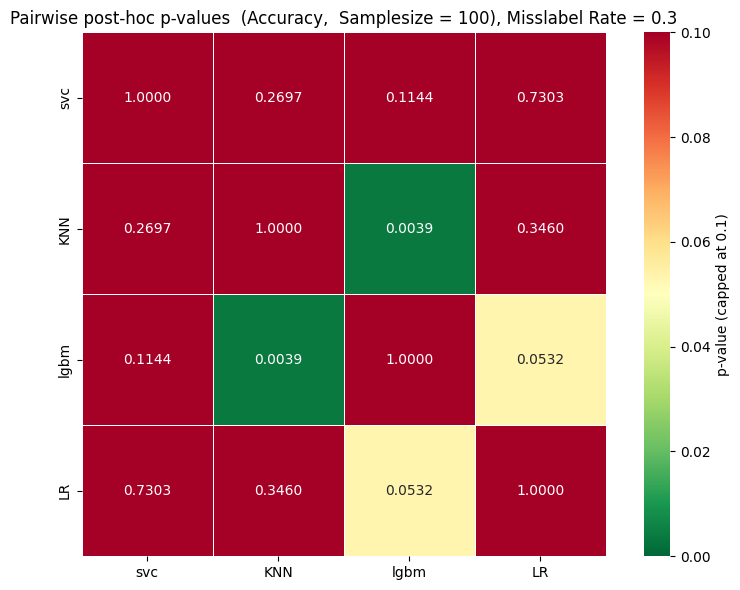

Friedman statistic: 11.3206, p-value: 0.01011258369737419
--------------------

Significant differences found among the methods for F1-Score at sample size 100.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.992367
  svc                  vs lgbm                : p-value = 0.002705
  svc                  vs LR                  : p-value = 0.414681
  KNN                  vs lgbm                : p-value = 0.004317
  KNN                  vs LR                  : p-value = 0.774053
  lgbm                 vs LR                  : p-value = 0.002526

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  1.000000  0.015154  1.000000
KNN   1.000000  1.000000  0.017268  1.000000
lgbm  0.015154  0.017268  1.000000  0.015154
LR    1.000000  1.000000  0.015154  1.000000


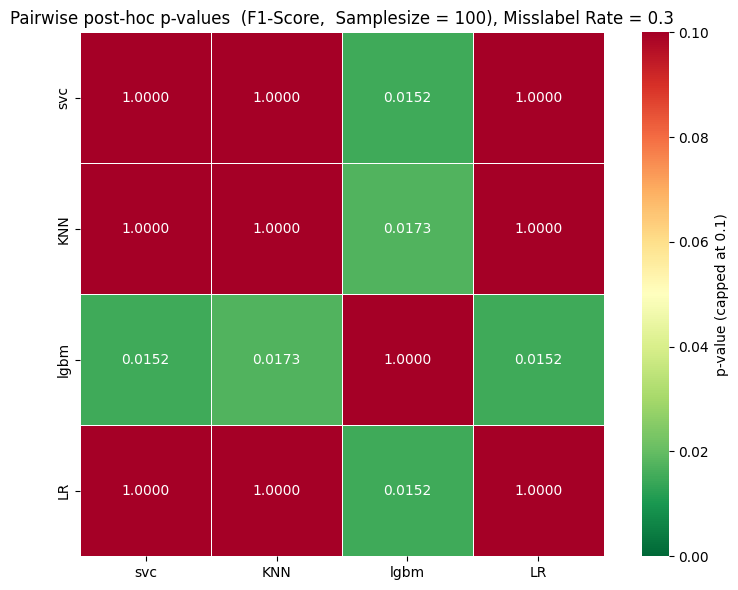

Friedman statistic: 121.8795, p-value: 3.038259087582224e-26
--------------------

Significant differences found among the methods for Accuracy at sample size 10000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000027
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.001665

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  5.377176e-05  1.065814e-14
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  5.377176e-05  1.065814e-14  1.000000e+00  1.665359e-03
LR    1.065814e-14  1.065814e-14  1.665359e-03  1.000000e+00


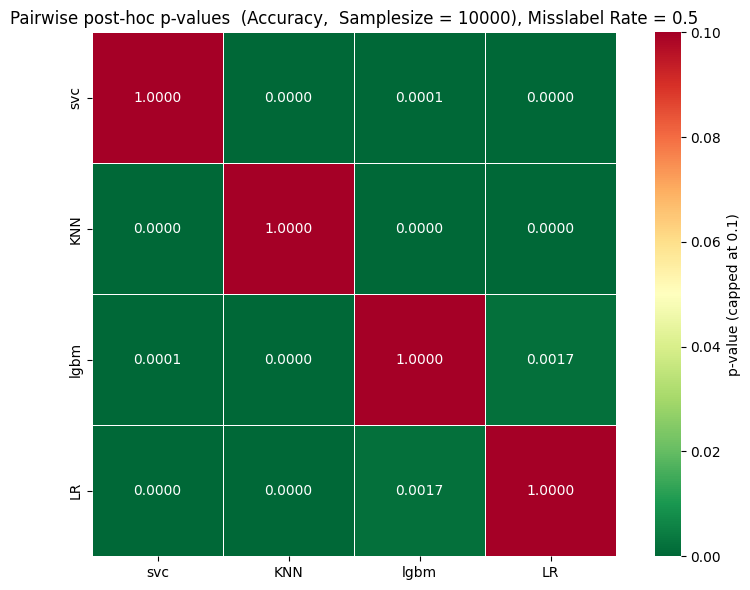

Friedman statistic: 123.4320, p-value: 1.4067353419001224e-26
--------------------

Significant differences found among the methods for F1-Score at sample size 10000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000001
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.004912

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  1.544694e-06  1.065814e-14
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  1.544694e-06  1.065814e-14  1.000000e+00  4.912361e-03
LR    1.065814e-14  1.065814e-14  4.912361e-03  1.000000e+00


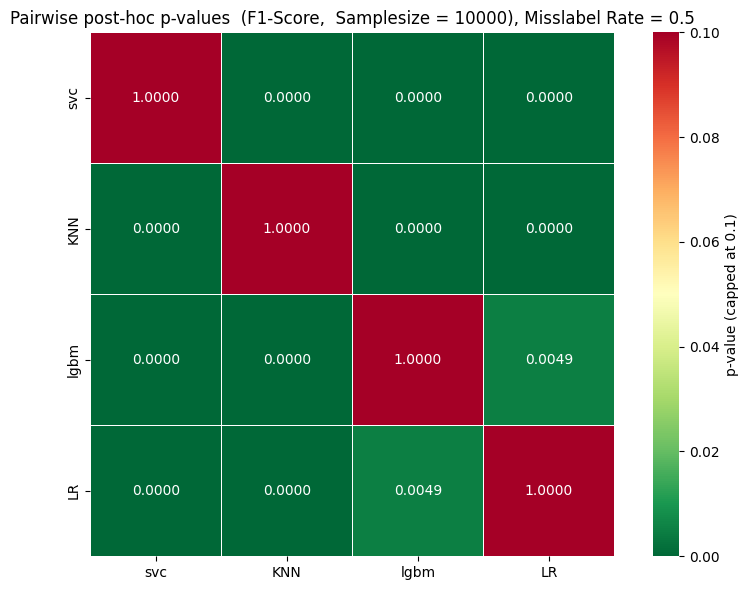

Friedman statistic: 132.7515, p-value: 1.3805978533915406e-28
--------------------

Significant differences found among the methods for Accuracy at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.087558
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  1.012523e-13  8.755848e-02
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  1.012523e-13  1.065814e-14  1.000000e+00  3.234906e-09
LR    8.755848e-02  1.065814e-14  3.234906e-09  1.000000e+00


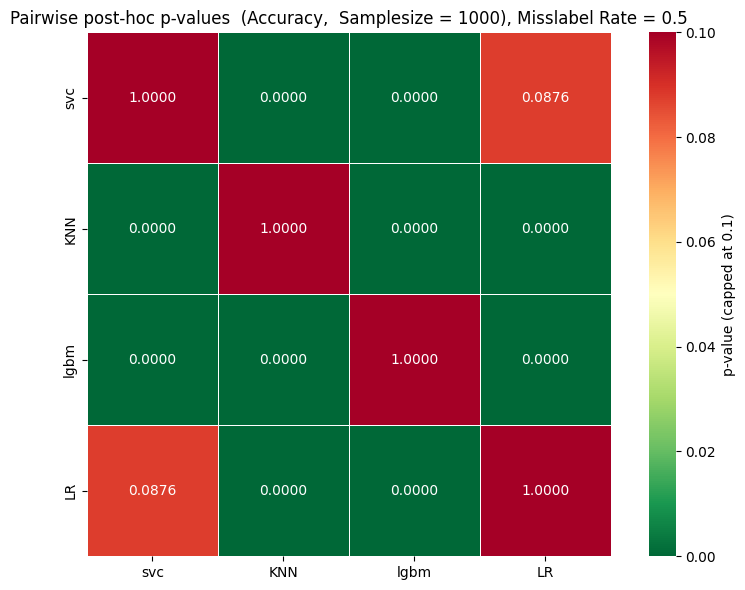

Friedman statistic: 129.9120, p-value: 5.649858221031353e-28
--------------------

Significant differences found among the methods for F1-Score at sample size 1000.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.233529
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values

               svc           KNN          lgbm            LR
svc   1.000000e+00  1.065814e-14  4.867218e-13  2.335290e-01
KNN   1.065814e-14  1.000000e+00  1.065814e-14  1.065814e-14
lgbm  4.867218e-13  1.065814e-14  1.000000e+00  5.329071e-14
LR    2.335290e-01  1.065814e-14  5.329071e-14  1.000000e+00


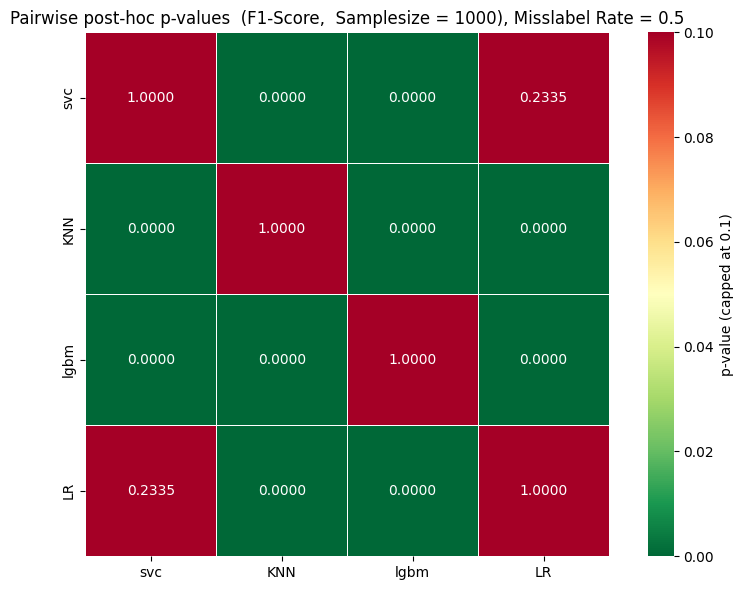

Friedman statistic: 31.1891, p-value: 7.75587774450739e-07
--------------------

Significant differences found among the methods for Accuracy at sample size 100.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000862
  svc                  vs lgbm                : p-value = 0.028252
  svc                  vs LR                  : p-value = 0.100815
  KNN                  vs lgbm                : p-value = 0.000004
  KNN                  vs LR                  : p-value = 0.000007
  lgbm                 vs LR                  : p-value = 0.231310

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.003447  0.084757  0.201631
KNN   0.003447  1.000000  0.000021  0.000034
lgbm  0.084757  0.000021  1.000000  0.231310
LR    0.201631  0.000034  0.231310  1.000000


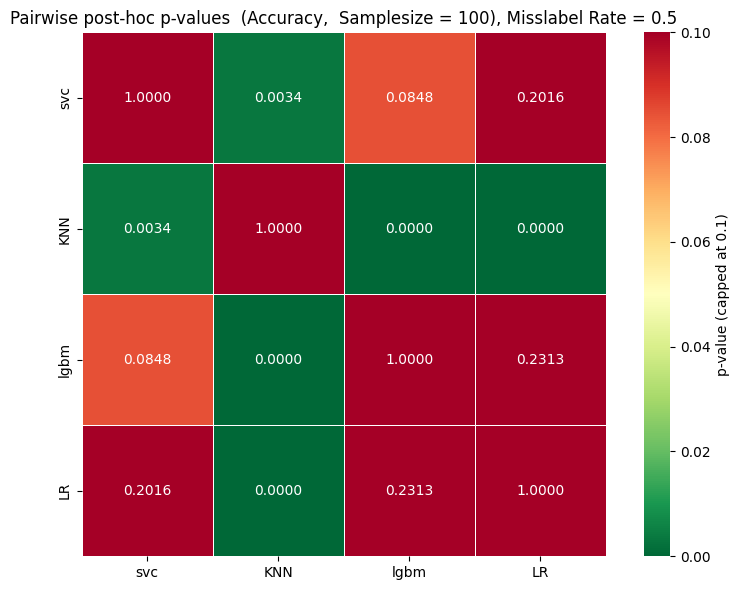

Friedman statistic: 24.4389, p-value: 2.022718398878032e-05
--------------------

Significant differences found among the methods for F1-Score at sample size 100.
Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.072377
  svc                  vs lgbm                : p-value = 0.003786
  svc                  vs LR                  : p-value = 0.014598
  KNN                  vs lgbm                : p-value = 0.000008
  KNN                  vs LR                  : p-value = 0.000072
  lgbm                 vs LR                  : p-value = 0.420723

Holm-Bonferroni Corrected p-values

           svc       KNN      lgbm        LR
svc   1.000000  0.144755  0.015146  0.043795
KNN   0.144755  1.000000  0.000045  0.000358
lgbm  0.015146  0.000045  1.000000  0.420723
LR    0.043795  0.000358  0.420723  1.000000


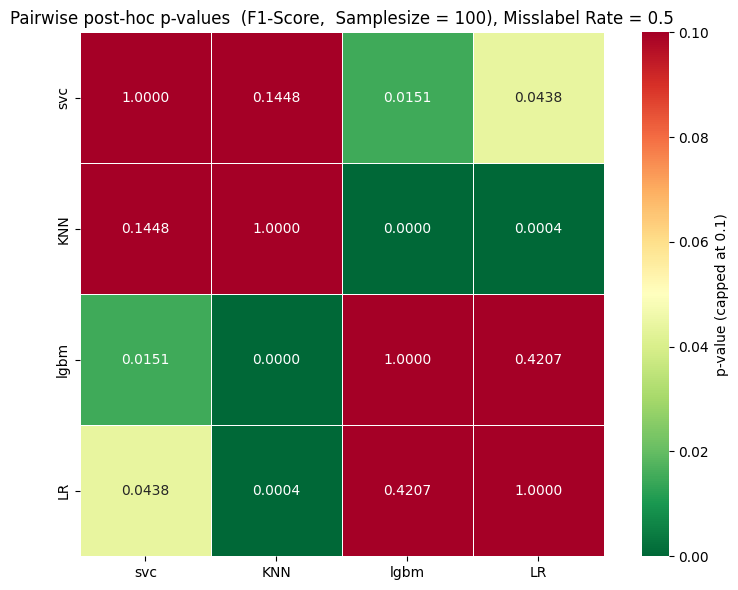

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, rankdata
import scikit_posthocs as sp
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def friedman(scores, method_names, sample_size, comparison_metric_name="Accuracy"):
    stat, pval = friedmanchisquare(*scores.T) 
    print(f"Friedman statistic: {stat:.4f}, p-value: {pval}")
    if pval > 0.05:
        print("-"*20)
        print(f"\nNo significant differences found among the methods for {comparison_metric_name} at sample size {sample_size}.")
    else:
        print("-"*20)
        print(f"\nSignificant differences found among the methods for {comparison_metric_name} at sample size {sample_size}.")
        print("Performing pairwise post-hoc test")
        n_methods = scores.shape[1]
        method_names = list(method_names)
        pvals_raw = []
        comparisons = []

        print("\nPairwise Comparisons:")
        for i, j in combinations(range(n_methods), 2):
            w_stat, w_pval = wilcoxon(scores[:, i], scores[:, j])
            pvals_raw.append(w_pval)
            comparisons.append((method_names[i], method_names[j]))
            print(f"  {method_names[i]:20s} vs {method_names[j]:20s}: p-value = {w_pval:.6f}")
        pvals_raw = np.array(pvals_raw)
        reject, pvals_corrected, _, _ = multipletests(pvals_raw, method='holm')

        p_matrix = pd.DataFrame(np.full((n_methods, n_methods), np.nan), 
                                index=method_names, 
                                columns=method_names)

        idx_counter = 0
        for i, j in combinations(range(n_methods), 2):
            p_matrix.iloc[j, i] = pvals_corrected[idx_counter]
            p_matrix.iloc[i, j] = pvals_corrected[idx_counter]
            idx_counter += 1

        np.fill_diagonal(p_matrix.values, 1.0)

        print("\n" + "=" * 70)
        print("Holm-Bonferroni Corrected p-values")
        print("=" * 70)
        print("\n" + p_matrix.to_string())
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(p_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r',
                    vmin=0, vmax=0.1, cbar_kws={'label': 'p-value (capped at 0.1)'},
                    ax=ax, square=True, linewidths=0.5)
        plt.title(f'Pairwise post-hoc p-values  ({comparison_metric_name},  Samplesize = {sample_size}), Misslabel Rate = {miss_label_rate}')
        plt.tight_layout()
        plt.savefig(f"imgs/posthoc_pvalues_{comparison_metric_name}_{sample_size}_{miss_label_rate}.png")
        plt.show()

for miss_label_rate in miss_label_rates:
    for sample_size in sample_sizes:
        friedman(sample_accs[sample_size, miss_label_rate], list(methods.keys()), sample_size=sample_size, comparison_metric_name="Accuracy")
        friedman(sample_f1s[sample_size, miss_label_rate], list(methods.keys()), sample_size=sample_size, comparison_metric_name="F1-Score")
    